# 06 — Evaluation & Poster Figures

Generate all figures for the technical poster: event visualization, architecture comparison,
ablation results, qualitative grids, attention maps, flow fields, motion-stratified analysis,
training curves, and GIF comparisons.

All figures saved as **300 dpi PNGs** to `/content/drive/MyDrive/493Project/figures/`.

In [1]:
# Cell 1a: Mount Drive + set paths
import sys, os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT = '/content/drive/MyDrive/493Project' if IN_COLAB else '.'
sys.path.insert(0, PROJECT)

Mounted at /content/drive


In [2]:
# Cell 1b: Install deps
import subprocess
try:
    import torchmetrics
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torchmetrics'])

In [3]:
# Cell 1c: Imports
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from collections import OrderedDict
import json, math, warnings
warnings.filterwarnings('ignore')

In [4]:
# Cell 1d: Project imports (force reload)
import importlib
import src.models, src.train, src.metrics, src.data, src.losses
for mod in [src.models, src.train, src.metrics, src.data, src.losses]:
    importlib.reload(mod)

from src.models import (
    RGBBaselineUNet, DualEncoderUNet, EventWarpNet, EventWarpNetV2,
    SizeAdapter, backwarp
)
from src.train import _forward, build_model
from src.metrics import calculate_psnr, calculate_ssim
from src.data import VimeoTripletDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

FIG_DIR = Path(PROJECT) / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures will be saved to: {FIG_DIR}')

Device: cuda
Figures will be saved to: /content/drive/MyDrive/493Project/figures


In [5]:
# Cell 2: Load all available models + val data
# ============================================================================
# Checkpoint registry — edit paths/names here if checkpoints move
# ============================================================================
CKPT_DIR = Path(PROJECT) / 'checkpoints'

CHECKPOINTS = OrderedDict({
    'RGB Baseline':        {'dir': 'vimeo_v6_baseline',      'model_type': 'baseline'},
    'DualEncoder (zero)':  {'dir': 'vimeo_v6_dual_zero',     'model_type': 'dual'},
    'DualEncoder':         {'dir': 'vimeo_v6_dual',          'model_type': 'dual'},
    'DualEncoder+Perc':    {'dir': 'vimeo_v6_dual_combined', 'model_type': 'dual'},
    'EventWarpNet v1':     {'dir': 'vimeo_v7_warp',          'model_type': 'warp'},
    'EventWarpNetV2':      {'dir': 'vimeo_v8_warp_v2',       'model_type': 'warp_v2'},
    'EventWarpNetV2+Perc': {'dir': 'vimeo_v9_warp_v2_perc',  'model_type': 'warp_v2'},
})

# --- Load models (gracefully skip missing or incompatible) ---
models_dict = OrderedDict()
for name, info in CHECKPOINTS.items():
    ckpt_path = CKPT_DIR / info['dir'] / 'best_model.pth'
    if not ckpt_path.exists():
        print(f'[SKIP] {name}: {ckpt_path} not found')
        continue
    cfg = {'model_type': info['model_type']}
    model = build_model(cfg, device)
    state = torch.load(str(ckpt_path), map_location=device, weights_only=True)
    try:
        model.load_state_dict(state)
    except RuntimeError as e:
        print(f'[SKIP] {name}: incompatible checkpoint ({e.__class__.__name__})')
        continue
    model.eval()
    models_dict[name] = model
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'[OK]   {name}: {n_params:.1f}M params')

print(f'\nLoaded {len(models_dict)}/{len(CHECKPOINTS)} models')

# --- Load val data ---
# Same extraction logic as 01_train.ipynb Cell 4:
# processed.tar on Drive → extract to local SSD → load split lists
import subprocess, random

VIMEO_ROOT = os.path.join(PROJECT, 'data', 'vimeo')
LOCAL_ROOT = '/content/local_vimeo'

if IN_COLAB:
    os.makedirs(LOCAL_ROOT, exist_ok=True)
    tar_on_drive = os.path.join(VIMEO_ROOT, 'processed.tar')
    marker = os.path.join(LOCAL_ROOT, '.copy_done')

    if not os.path.exists(marker):
        assert os.path.exists(tar_on_drive), \
            f'processed.tar not found at {tar_on_drive} — run 00b_tar_processed.ipynb first'

        # Install pv for progress display (same as 01_train)
        subprocess.run(['apt-get', 'install', '-qq', '-y', 'pv'], capture_output=True)

        total_bytes = os.path.getsize(tar_on_drive)
        print(f'Extracting processed.tar ({total_bytes / 1e9:.1f} GB) to local SSD...')
        subprocess.run(
            f'pv -f -s {total_bytes} "{tar_on_drive}" | tar xf - -C "{LOCAL_ROOT}"',
            shell=True, check=True,
        )
        open(marker, 'w').close()
        print('Done.')
    else:
        print('Local data already extracted.')
else:
    LOCAL_ROOT = VIMEO_ROOT

# Load split lists and resolve to local paths (same as 01_train)
def load_split(split_file):
    path = os.path.join(VIMEO_ROOT, split_file)
    if not os.path.exists(path):
        return []
    with open(path) as f:
        entries = [line.strip() for line in f if line.strip()]
    dirs = []
    for rel in entries:
        d = os.path.join(LOCAL_ROOT, rel)
        if os.path.isdir(d):
            dirs.append(d)
    return dirs

train_dirs = load_split('tri_trainlist.txt')
val_dirs   = load_split('tri_vallist.txt')

# If val is empty, split from train 90/10 (same fallback as 01_train)
if len(val_dirs) == 0 and len(train_dirs) > 0:
    print(f'No processed val triplets found — splitting 90/10 from {len(train_dirs)} train entries')
    rng_split = random.Random(42)
    all_entries = list(train_dirs)
    rng_split.shuffle(all_entries)
    n_val = max(1, int(len(all_entries) * 0.10))
    val_dirs   = all_entries[:n_val]
    train_dirs = all_entries[n_val:]

# Last resort: glob for triplets
if len(val_dirs) == 0:
    all_dirs = sorted([
        str(Path(p).parent) for p in Path(LOCAL_ROOT).rglob('im2.png')
        if (Path(p).parent / 'voxel.pt').exists()
    ])
    if all_dirs:
        print(f'No split files — discovered {len(all_dirs)} triplets via glob')
        rng_split = random.Random(42)
        rng_split.shuffle(all_dirs)
        n_val = max(1, int(len(all_dirs) * 0.10))
        val_dirs = all_dirs[:n_val]
    else:
        print('WARNING: No data found. Check paths.')

print(f'Train: {len(train_dirs)} | Val: {len(val_dirs)}')

val_ds = VimeoTripletDataset(val_dirs, patch_size=9999, augment=False)
print(f'Val dataset ready ({len(val_ds)} samples)')

[OK]   RGB Baseline: 17.3M params
[OK]   DualEncoder (zero): 27.9M params
[OK]   DualEncoder: 27.9M params
[OK]   DualEncoder+Perc: 27.9M params
[OK]   EventWarpNet v1: 13.4M params
[OK]   EventWarpNetV2: 15.1M params
[OK]   EventWarpNetV2+Perc: 15.1M params

Loaded 7/7 models
Extracting processed.tar (5.3 GB) to local SSD...
Done.
No processed val triplets found — splitting 90/10 from 1900 train entries
Train: 1710 | Val: 190
Val dataset ready (190 samples)


In [6]:
# Cell 2b: Helper functions used across figures
# ============================================================================

def pad_to_multiple(t, multiple=32):
    """Pad tensor (B,C,H,W) so H,W are divisible by `multiple`. Returns (padded, (pad_h, pad_w))."""
    _, _, h, w = t.shape
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    if pad_h > 0 or pad_w > 0:
        t = F.pad(t, (0, pad_w, 0, pad_h), mode='reflect')
    return t, (pad_h, pad_w)

def unpad(t, pad_hw):
    """Remove padding added by pad_to_multiple."""
    ph, pw = pad_hw
    if ph > 0:
        t = t[:, :, :-ph, :]
    if pw > 0:
        t = t[:, :, :, :-pw]
    return t

@torch.no_grad()
def run_inference(model, f0, f1, voxel):
    """Run model on a single sample with padding. Returns pred (B,3,H,W) clamped to [0,1]."""
    f0p, pad_hw = pad_to_multiple(f0)
    f1p, _      = pad_to_multiple(f1)
    vp,  _      = pad_to_multiple(voxel)
    outputs = _forward(model, f0p, f1p, vp)
    pred = outputs[0].clamp(0, 1)
    return unpad(pred, pad_hw), outputs

def to_numpy(t):
    """(B,C,H,W) or (C,H,W) tensor → (H,W,C) numpy in [0,1]."""
    if t.dim() == 4:
        t = t[0]
    return t.detach().cpu().permute(1, 2, 0).numpy().clip(0, 1)

def save_fig(fig, name, dpi=300):
    """Save figure to FIG_DIR and display."""
    path = FIG_DIR / f'{name}.png'
    fig.savefig(str(path), dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')
    plt.show()
    plt.close(fig)

def load_sample(idx):
    """Load a val sample and move to device. Returns (f0, f1, voxel, gt) each (1,C,H,W)."""
    f0, f1, voxel, gt = val_ds[idx]
    return f0.unsqueeze(0).to(device), f1.unsqueeze(0).to(device), \
           voxel.unsqueeze(0).to(device), gt.unsqueeze(0).to(device)

print('Helper functions ready.')

Helper functions ready.


Computing event densities for sample selection...
Saved: /content/drive/MyDrive/493Project/figures/fig1_what_events_encode.png


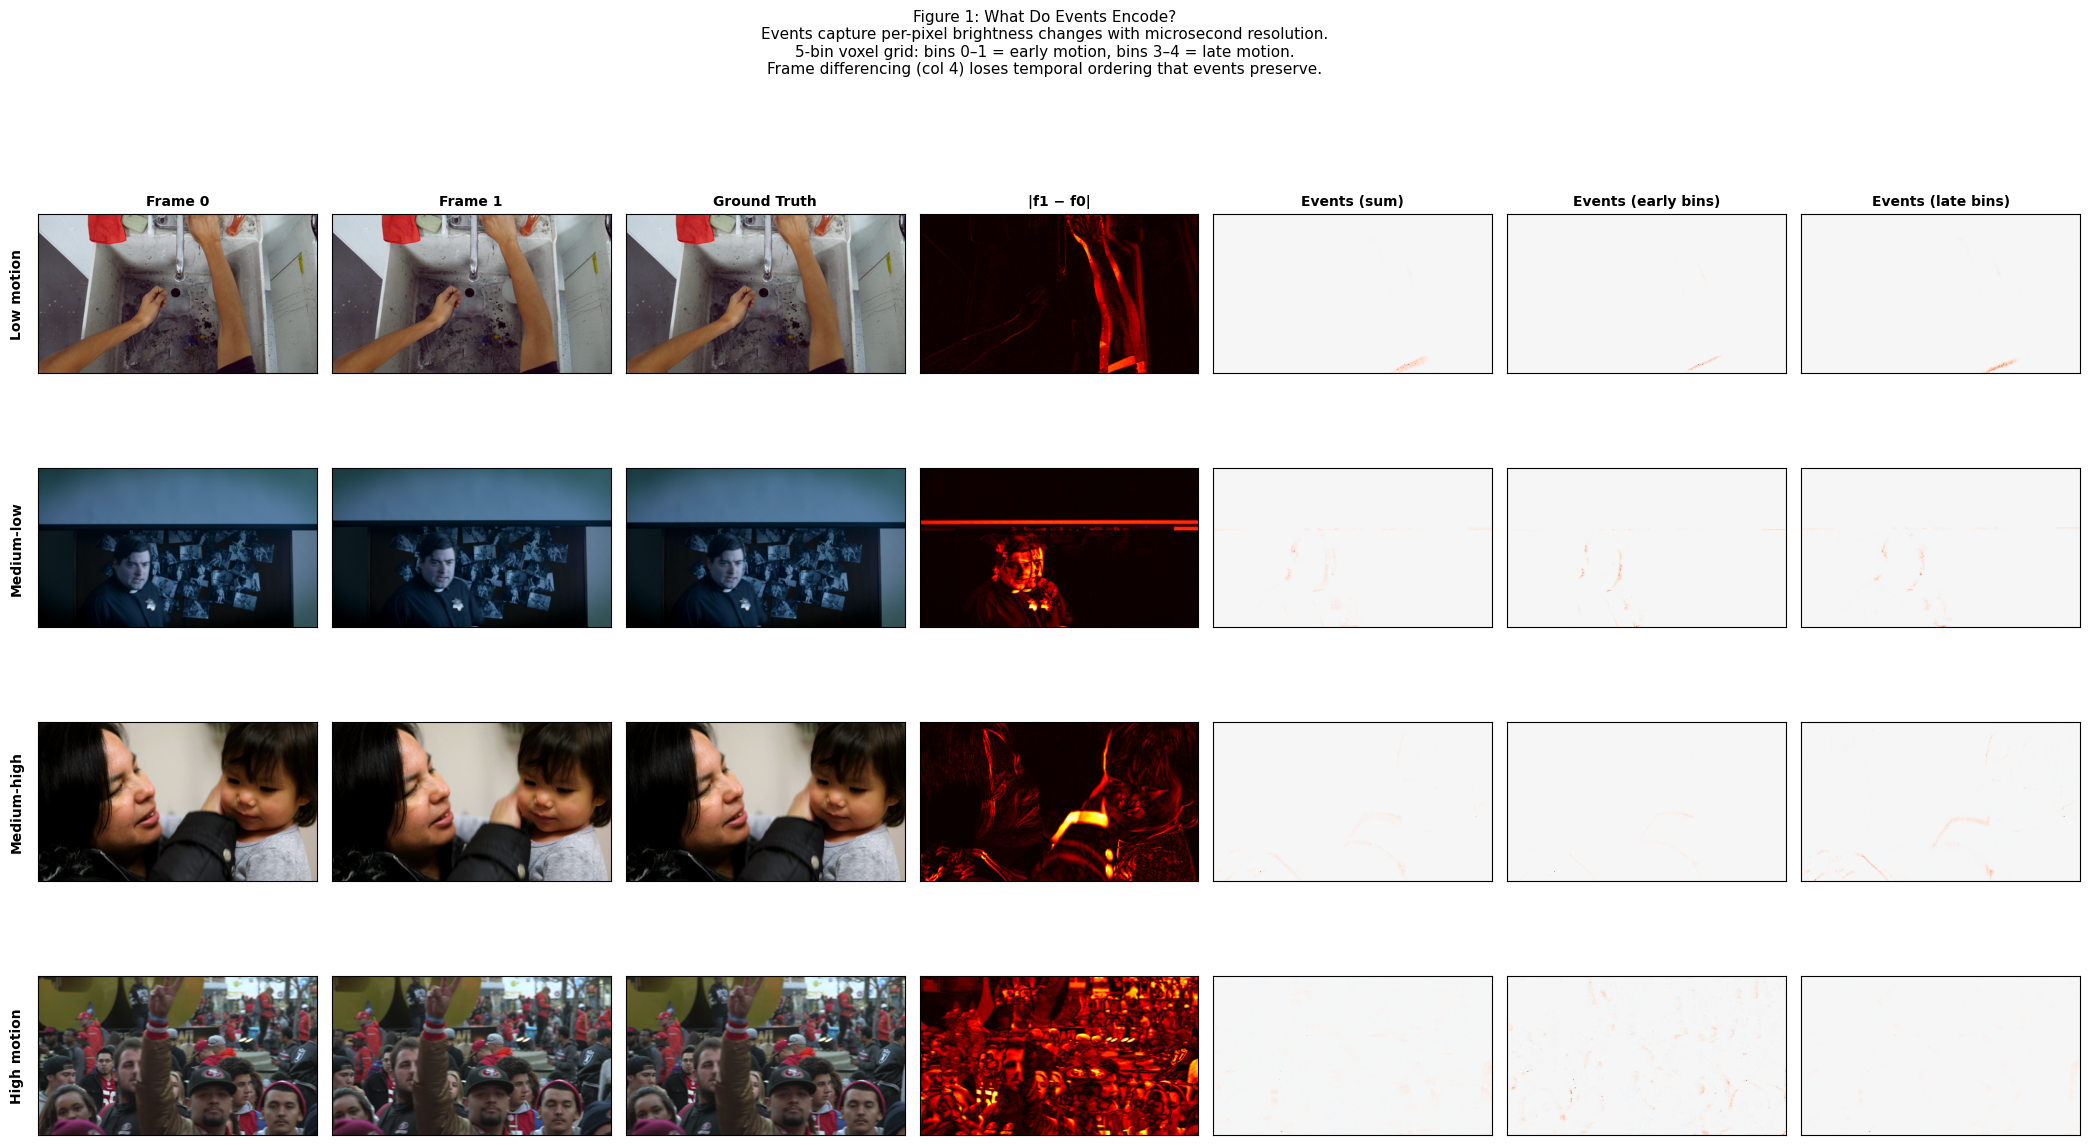

In [7]:
# Cell 3: Figure 1 — "What Do Events Encode?"
# ============================================================================
# Pick 4 val clips with varying motion levels (by event density)
# Show: f0 | f1 | GT | |f1-f0| | Event sum | Per-bin temporal decomposition

# Compute event density for all val samples to pick diverse examples
print('Computing event densities for sample selection...')
densities = []
for i in range(len(val_ds)):
    _, _, voxel_i, _ = val_ds[i]
    densities.append(voxel_i.abs().sum().item())
densities = np.array(densities)

# Pick: min, 33rd percentile, 67th, max
pcts = [0, 33, 67, 100]
sample_indices = []
for p in pcts:
    target = np.percentile(densities, p)
    idx = int(np.argmin(np.abs(densities - target)))
    if idx in sample_indices:  # avoid duplicates
        candidates = np.argsort(np.abs(densities - target))
        for c in candidates:
            if int(c) not in sample_indices:
                idx = int(c)
                break
    sample_indices.append(idx)

motion_labels = ['Low motion', 'Medium-low', 'Medium-high', 'High motion']

fig, axes = plt.subplots(len(sample_indices), 7, figsize=(21, 3 * len(sample_indices)))
col_titles = ['Frame 0', 'Frame 1', 'Ground Truth', '|f1 − f0|',
              'Events (sum)', 'Events (early bins)', 'Events (late bins)']

for row, (si, label) in enumerate(zip(sample_indices, motion_labels)):
    f0, f1, voxel, gt = load_sample(si)
    f0n, f1n, gtn = to_numpy(f0), to_numpy(f1), to_numpy(gt)
    voxel_np = voxel[0].cpu().numpy()  # (5, H, W)

    # Frame difference
    frame_diff = np.abs(f1n - f0n).mean(axis=-1)

    # Event visualizations
    event_sum = voxel_np.sum(axis=0)  # sum across all bins
    early_bins = voxel_np[:2].sum(axis=0)  # bins 0-1: early motion
    late_bins = voxel_np[3:].sum(axis=0)   # bins 3-4: late motion

    panels = [f0n, f1n, gtn, frame_diff, event_sum, early_bins, late_bins]
    cmaps  = [None, None, None, 'hot', 'RdBu_r', 'RdBu_r', 'RdBu_r']

    for col, (panel, cmap) in enumerate(zip(panels, cmaps)):
        ax = axes[row, col]
        if cmap is None:
            ax.imshow(panel)
        else:
            vmax = max(abs(panel.min()), abs(panel.max())) if 'RdBu' in str(cmap) else None
            vmin = -vmax if vmax else None
            ax.imshow(panel, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(label, fontsize=10, fontweight='bold', rotation=90, labelpad=10)

fig.suptitle('Figure 1: What Do Events Encode?\n'
             'Events capture per-pixel brightness changes with microsecond resolution.\n'
             '5-bin voxel grid: bins 0–1 = early motion, bins 3–4 = late motion.\n'
             'Frame differencing (col 4) loses temporal ordering that events preserve.',
             fontsize=11, y=1.02)
fig.tight_layout()
save_fig(fig, 'fig1_what_events_encode')

Saved: /content/drive/MyDrive/493Project/figures/fig2_architecture_comparison.png


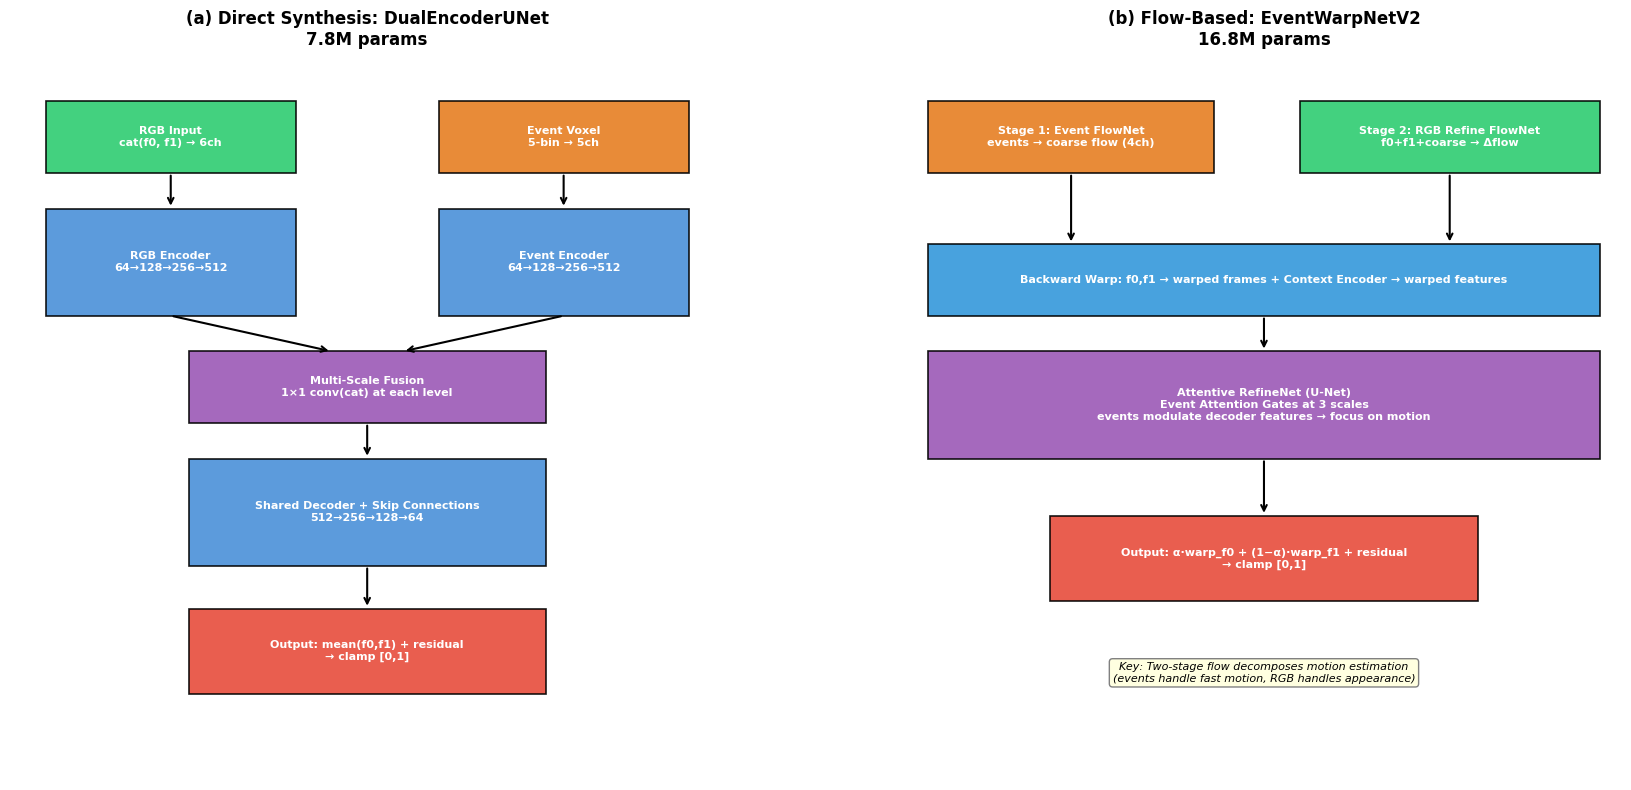

In [8]:
# Cell 4: Figure 2 — Architecture Comparison Diagram
# ============================================================================
# Side-by-side block diagrams: Direct Synthesis (DualEncoderUNet) vs Flow-Based (EventWarpNetV2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- Helper to draw a labeled box ---
def draw_box(ax, xy, w, h, text, color='#4A90D9', fontsize=8, text_color='white'):
    rect = plt.Rectangle(xy, w, h, facecolor=color, edgecolor='black', linewidth=1.2,
                          alpha=0.9, zorder=2)
    ax.add_patch(rect)
    ax.text(xy[0] + w/2, xy[1] + h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=text_color, zorder=3)

def draw_arrow(ax, start, end, color='black'):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# ===== LEFT: DualEncoderUNet (Direct Synthesis) =====
ax1.set_xlim(0, 10); ax1.set_ylim(0, 10)
ax1.set_aspect('equal'); ax1.axis('off')
ax1.set_title('(a) Direct Synthesis: DualEncoderUNet\n7.8M params', fontsize=12, fontweight='bold', pad=15)

# Input blocks
draw_box(ax1, (0.5, 8.5), 3.5, 1, 'RGB Input\ncat(f0, f1) → 6ch', '#2ECC71')
draw_box(ax1, (6, 8.5), 3.5, 1, 'Event Voxel\n5-bin → 5ch', '#E67E22')

# Encoders
draw_box(ax1, (0.5, 6.5), 3.5, 1.5, 'RGB Encoder\n64→128→256→512', '#4A90D9')
draw_box(ax1, (6, 6.5), 3.5, 1.5, 'Event Encoder\n64→128→256→512', '#4A90D9')

# Fusion
draw_box(ax1, (2.5, 5), 5, 1, 'Multi-Scale Fusion\n1×1 conv(cat) at each level', '#9B59B6')

# Decoder
draw_box(ax1, (2.5, 3), 5, 1.5, 'Shared Decoder + Skip Connections\n512→256→128→64', '#4A90D9')

# Output
draw_box(ax1, (2.5, 1.2), 5, 1.2, 'Output: mean(f0,f1) + residual\n→ clamp [0,1]', '#E74C3C')

# Arrows
draw_arrow(ax1, (2.25, 8.5), (2.25, 8.0))
draw_arrow(ax1, (7.75, 8.5), (7.75, 8.0))
draw_arrow(ax1, (2.25, 6.5), (4.5, 6.0))
draw_arrow(ax1, (7.75, 6.5), (5.5, 6.0))
draw_arrow(ax1, (5, 5), (5, 4.5))
draw_arrow(ax1, (5, 3), (5, 2.4))

# ===== RIGHT: EventWarpNetV2 (Flow-Based) =====
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title('(b) Flow-Based: EventWarpNetV2\n16.8M params', fontsize=12, fontweight='bold', pad=15)

# Stage 1
draw_box(ax2, (0.3, 8.5), 4, 1, 'Stage 1: Event FlowNet\nevents → coarse flow (4ch)', '#E67E22')
draw_box(ax2, (5.5, 8.5), 4.2, 1, 'Stage 2: RGB Refine FlowNet\nf0+f1+coarse → Δflow', '#2ECC71')

# Warp
draw_box(ax2, (0.3, 6.5), 9.4, 1, 'Backward Warp: f0,f1 → warped frames + Context Encoder → warped features',
         '#3498DB')

# RefineNet
draw_box(ax2, (0.3, 4.5), 9.4, 1.5, 'Attentive RefineNet (U-Net)\nEvent Attention Gates at 3 scales\n'
         'events modulate decoder features → focus on motion', '#9B59B6')

# Output
draw_box(ax2, (2, 2.5), 6, 1.2, 'Output: α·warp_f0 + (1−α)·warp_f1 + residual\n→ clamp [0,1]', '#E74C3C')

# Arrows
draw_arrow(ax2, (2.3, 8.5), (2.3, 7.5))
draw_arrow(ax2, (7.6, 8.5), (7.6, 7.5))
draw_arrow(ax2, (5, 6.5), (5, 6.0))
draw_arrow(ax2, (5, 4.5), (5, 3.7))

# Key difference annotation
ax2.text(5, 1.5, 'Key: Two-stage flow decomposes motion estimation\n'
         '(events handle fast motion, RGB handles appearance)',
         ha='center', va='center', fontsize=8, fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

fig.tight_layout(w_pad=3)
save_fig(fig, 'fig2_architecture_comparison')

Evaluating RGB Baseline...
  PSNR: 29.95 ± 4.71 dB | SSIM: 0.8708 ± 0.1114
Evaluating DualEncoder (zero)...
  PSNR: 28.00 ± 3.99 dB | SSIM: 0.8296 ± 0.1153
Evaluating DualEncoder...
  PSNR: 31.00 ± 4.51 dB | SSIM: 0.8860 ± 0.0978
Evaluating DualEncoder+Perc...
  PSNR: 31.24 ± 4.55 dB | SSIM: 0.8910 ± 0.0957
Evaluating EventWarpNet v1...
  PSNR: 32.73 ± 4.69 dB | SSIM: 0.9219 ± 0.0795
Evaluating EventWarpNetV2...
  PSNR: 33.83 ± 4.49 dB | SSIM: 0.9408 ± 0.0651
Evaluating EventWarpNetV2+Perc...
  PSNR: 34.09 ± 4.55 dB | SSIM: 0.9450 ± 0.0627

Model                     PSNR (dB)          SSIM              
----------------------------------------------------------------------
RGB Baseline              29.95 ± 4.71      0.8708 ± 0.1114
DualEncoder (zero)        28.00 ± 3.99      0.8296 ± 0.1153
DualEncoder               31.00 ± 4.51      0.8860 ± 0.0978
DualEncoder+Perc          31.24 ± 4.55      0.8910 ± 0.0957
EventWarpNet v1           32.73 ± 4.69      0.9219 ± 0.0795
EventWarpNetV2    

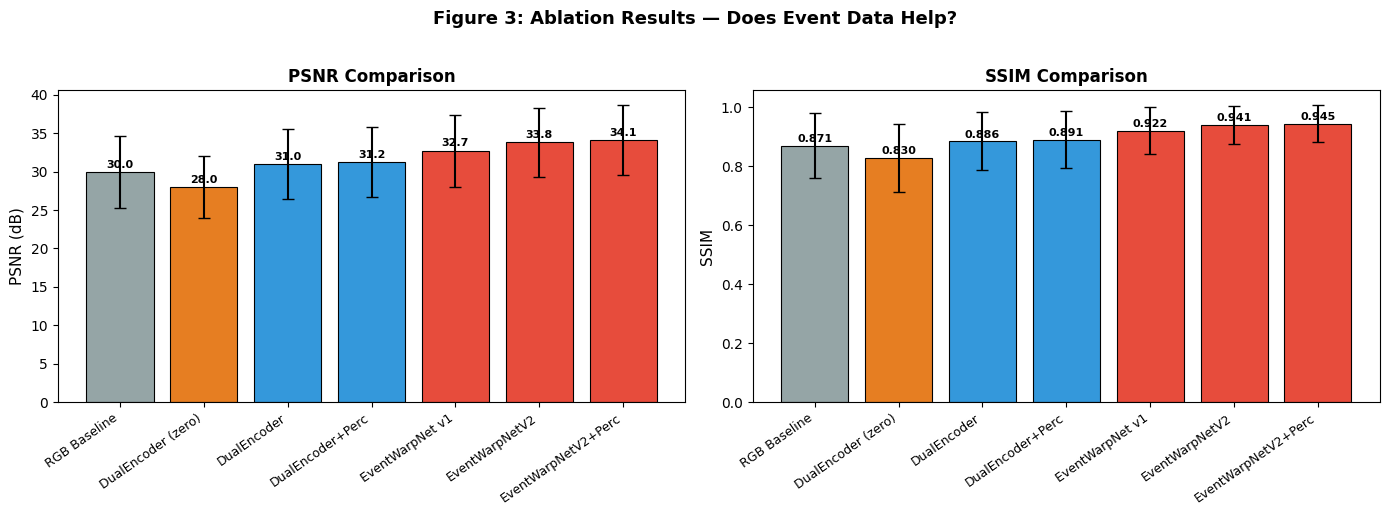

In [9]:
# Cell 5: Figure 3 — Ablation Table + Bar Chart
# ============================================================================
# Run inference on full val set for each loaded model, compute PSNR/SSIM

from torch.utils.data import DataLoader

val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

results = OrderedDict()
for name, model in models_dict.items():
    print(f'Evaluating {name}...')
    psnr_list, ssim_list = [], []
    model.eval()
    for f0, f1, voxel, gt in val_loader:
        f0, f1, voxel, gt = f0.to(device), f1.to(device), voxel.to(device), gt.to(device)
        pred, _ = run_inference(model, f0, f1, voxel)
        psnr_list.append(calculate_psnr(pred, gt).item())
        ssim_list.append(calculate_ssim(pred, gt).item())
    results[name] = {
        'psnr_mean': np.mean(psnr_list),
        'psnr_std':  np.std(psnr_list),
        'ssim_mean': np.mean(ssim_list),
        'ssim_std':  np.std(ssim_list),
        'psnr_all':  psnr_list,
        'ssim_all':  ssim_list,
    }
    print(f'  PSNR: {results[name]["psnr_mean"]:.2f} ± {results[name]["psnr_std"]:.2f} dB | '
          f'SSIM: {results[name]["ssim_mean"]:.4f} ± {results[name]["ssim_std"]:.4f}')

# --- Print table ---
print('\n' + '='*70)
print(f'{"Model":<25} {"PSNR (dB)":<18} {"SSIM":<18}')
print('-'*70)
for name, r in results.items():
    print(f'{name:<25} {r["psnr_mean"]:.2f} ± {r["psnr_std"]:.2f}      '
          f'{r["ssim_mean"]:.4f} ± {r["ssim_std"]:.4f}')
print('='*70)

# --- Bar chart ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
names = list(results.keys())
psnr_means = [results[n]['psnr_mean'] for n in names]
psnr_stds  = [results[n]['psnr_std']  for n in names]
ssim_means = [results[n]['ssim_mean'] for n in names]
ssim_stds  = [results[n]['ssim_std']  for n in names]

# Color by model family
colors = []
for n in names:
    if 'Baseline' in n:
        colors.append('#95a5a6')
    elif 'zero' in n:
        colors.append('#e67e22')
    elif 'WarpNet' in n or 'Warp' in n:
        colors.append('#e74c3c')
    else:
        colors.append('#3498db')

bars1 = ax1.bar(range(len(names)), psnr_means, yerr=psnr_stds, capsize=4,
                color=colors, edgecolor='black', linewidth=0.8)
ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax1.set_ylabel('PSNR (dB)', fontsize=11)
ax1.set_title('PSNR Comparison', fontsize=12, fontweight='bold')
# Add value labels
for bar, val in zip(bars1, psnr_means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

bars2 = ax2.bar(range(len(names)), ssim_means, yerr=ssim_stds, capsize=4,
                color=colors, edgecolor='black', linewidth=0.8)
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('SSIM', fontsize=11)
ax2.set_title('SSIM Comparison', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, ssim_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('Figure 3: Ablation Results — Does Event Data Help?', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
save_fig(fig, 'fig3_ablation_bar_chart')

In [10]:
# Cell 6: Figure 4 — Qualitative Grid (Hero Figure)
# ============================================================================
# Pick 4-6 val clips (mix of high/low motion), show GT + all model predictions + error maps

# Select 6 samples spanning motion range
qual_indices = []
for p in [5, 20, 40, 60, 80, 95]:
    target = np.percentile(densities, p)
    idx = int(np.argmin(np.abs(densities - target)))
    while idx in qual_indices:
        idx = (idx + 1) % len(densities)
    qual_indices.append(idx)

model_names = list(models_dict.keys())
n_models = len(model_names)
n_samples = len(qual_indices)

# 2 rows per sample (prediction + error), plus 1 column for GT
n_cols = n_models + 1  # GT + each model
n_rows = n_samples * 2  # pred row + error row per sample

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2.8 * n_samples))
if n_cols == 1:
    axes = axes.reshape(-1, 1)

for si_idx, si in enumerate(qual_indices):
    f0, f1, voxel, gt = load_sample(si)
    gt_np = to_numpy(gt)
    pred_row = si_idx * 2
    err_row  = si_idx * 2 + 1

    # GT column
    axes[pred_row, 0].imshow(gt_np)
    axes[pred_row, 0].set_title('GT' if si_idx == 0 else '', fontsize=9, fontweight='bold')
    axes[pred_row, 0].set_ylabel(f'Sample {si}', fontsize=8)
    axes[err_row, 0].imshow(np.zeros_like(gt_np))  # blank for GT error
    axes[err_row, 0].text(0.5, 0.5, 'Reference', ha='center', va='center',
                           transform=axes[err_row, 0].transAxes, fontsize=8, color='white')

    for mi, mname in enumerate(model_names):
        model = models_dict[mname]
        pred, _ = run_inference(model, f0, f1, voxel)
        pred_np = to_numpy(pred)

        # Per-sample PSNR
        psnr_val = calculate_psnr(pred, gt).item()

        # Prediction
        axes[pred_row, mi + 1].imshow(pred_np)
        title = f'{mname}\n' if si_idx == 0 else ''
        axes[pred_row, mi + 1].set_title(title, fontsize=7, fontweight='bold')
        axes[pred_row, mi + 1].text(0.02, 0.98, f'{psnr_val:.1f} dB',
                                     transform=axes[pred_row, mi + 1].transAxes,
                                     fontsize=7, color='yellow', fontweight='bold',
                                     va='top', ha='left',
                                     bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.6))

        # Error map (5x amplified)
        error = np.abs(pred_np - gt_np).mean(axis=-1) * 5.0
        axes[err_row, mi + 1].imshow(error, cmap='hot', vmin=0, vmax=1)
        if si_idx == 0:
            axes[err_row, mi + 1].set_title('Error ×5', fontsize=7)

# Remove ticks
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Figure 4: Qualitative Comparison Across Models\n'
             'Top row per sample: prediction | Bottom row: error map (×5 amplification)',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
save_fig(fig, 'fig4_qualitative_grid')

Output hidden; open in https://colab.research.google.com to view.

Using EventWarpNetV2 for attention visualization
Saved: /content/drive/MyDrive/493Project/figures/fig5_attention_gates.png


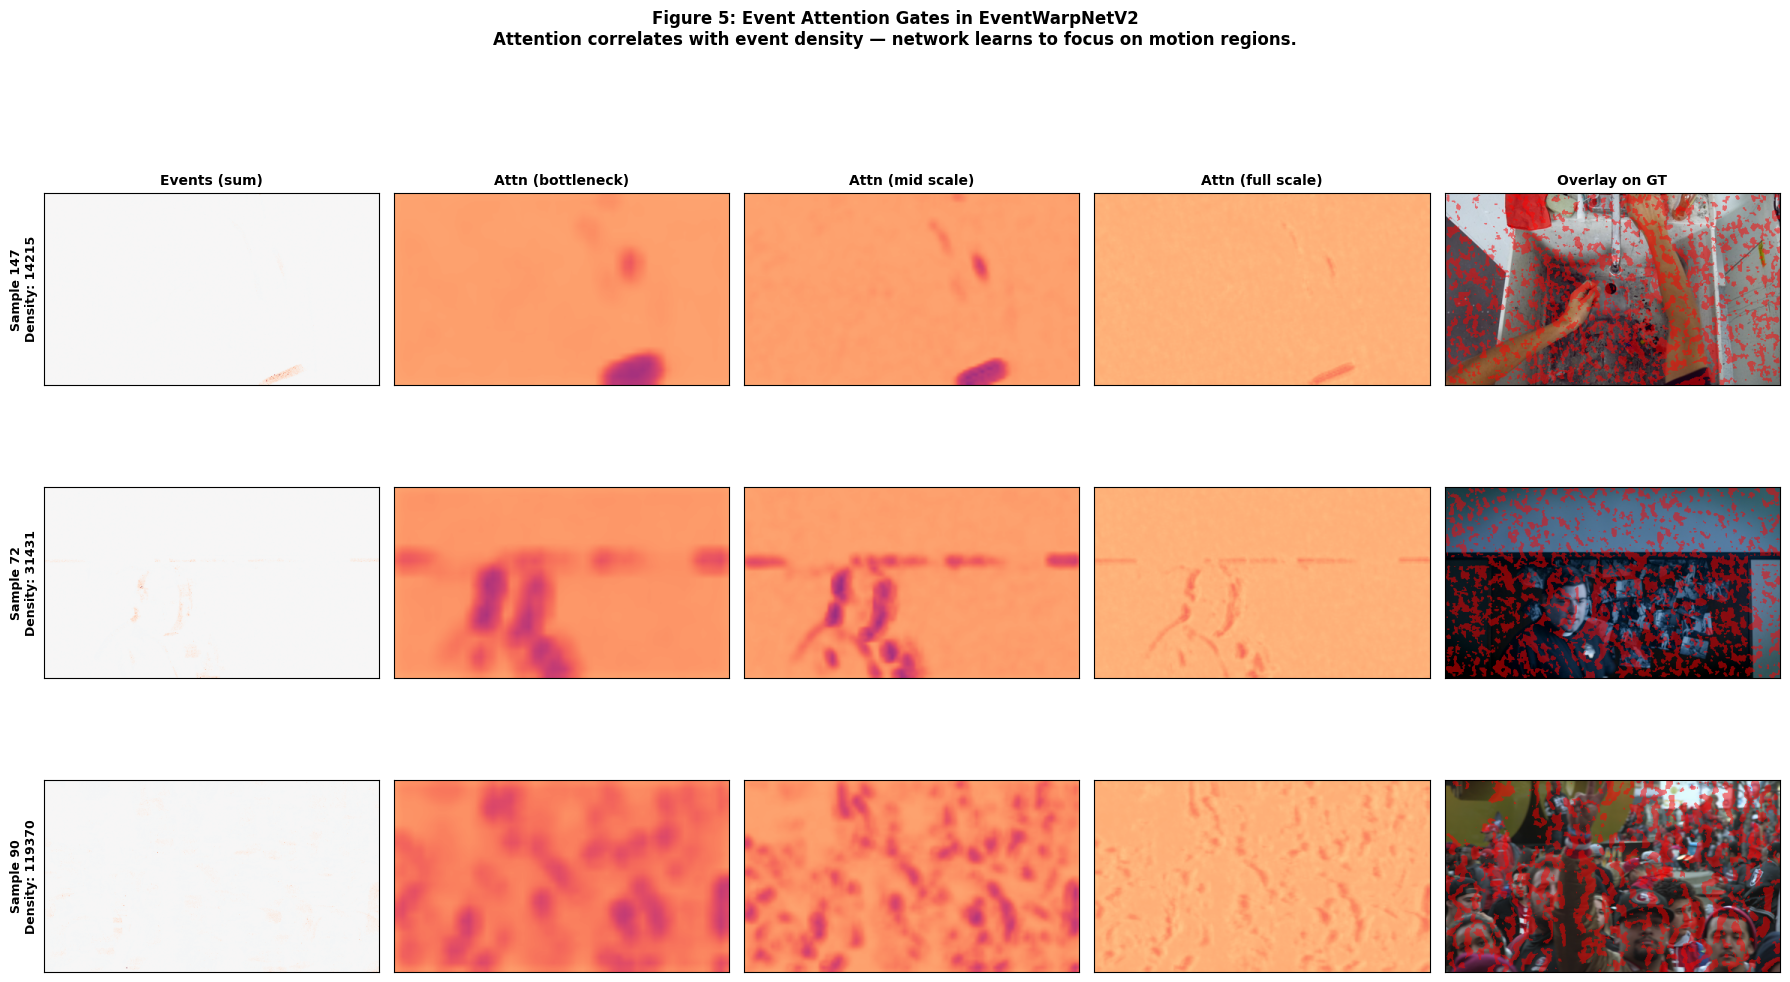

In [11]:
# Cell 7: Figure 5 — Event Attention Gates Visualization
# ============================================================================
# For EventWarpNetV2, extract attention maps from AttentiveRefineNet at 3 scales

# Find an EventWarpNetV2 model
warpv2_name = None
warpv2_model = None
for name, model in models_dict.items():
    if isinstance(model, EventWarpNetV2):
        warpv2_name = name
        warpv2_model = model
        break

if warpv2_model is None:
    print('No EventWarpNetV2 model loaded — skipping attention visualization.')
else:
    print(f'Using {warpv2_name} for attention visualization')

    # Hook into attention gates to capture their outputs
    attention_maps = {}

    def make_hook(gate_name):
        def hook_fn(module, input, output):
            # EventAttentionGate.forward returns features * attn
            # We want the attention itself: sigmoid(conv2(relu(gn(conv1(events)))))
            events = input[1]  # second argument to forward
            with torch.no_grad():
                attn = torch.sigmoid(
                    module.conv2(F.relu(module.gn(module.conv1(events))))
                )
            attention_maps[gate_name] = attn.detach().cpu()
        return hook_fn

    hooks = []
    refinenet = warpv2_model.refinenet
    hooks.append(refinenet.attn3.register_forward_hook(make_hook('attn3_bottleneck')))
    hooks.append(refinenet.attn2.register_forward_hook(make_hook('attn2_mid')))
    hooks.append(refinenet.attn1.register_forward_hook(make_hook('attn1_full')))

    # Pick 3 samples with varying motion
    attn_indices = [sample_indices[0], sample_indices[1], sample_indices[3]]  # low, med, high

    fig, axes = plt.subplots(len(attn_indices), 5, figsize=(18, 3.5 * len(attn_indices)))
    col_titles = ['Events (sum)', 'Attn (bottleneck)', 'Attn (mid scale)', 'Attn (full scale)', 'Overlay on GT']

    for row, si in enumerate(attn_indices):
        f0, f1, voxel, gt = load_sample(si)
        attention_maps.clear()

        # Run forward to trigger hooks
        pred, _ = run_inference(warpv2_model, f0, f1, voxel)

        gt_np = to_numpy(gt)
        voxel_sum = voxel[0].cpu().numpy().sum(axis=0)

        # Event density
        axes[row, 0].imshow(voxel_sum, cmap='RdBu_r',
                             vmin=-abs(voxel_sum).max(), vmax=abs(voxel_sum).max())
        if row == 0:
            axes[row, 0].set_title(col_titles[0], fontsize=10, fontweight='bold')
        axes[row, 0].set_ylabel(f'Sample {si}\nDensity: {densities[si]:.0f}',
                                  fontsize=9, fontweight='bold')

        # Attention maps at each scale
        for ci, (gate_name, title) in enumerate(zip(
            ['attn3_bottleneck', 'attn2_mid', 'attn1_full'],
            col_titles[1:4]
        )):
            if gate_name in attention_maps:
                attn = attention_maps[gate_name][0].mean(dim=0).numpy()  # avg over channels
                # Upsample to GT resolution for visualization
                attn_up = np.array(Image.fromarray(attn).resize(
                    (gt_np.shape[1], gt_np.shape[0]), Image.BILINEAR))
                axes[row, ci + 1].imshow(attn_up, cmap='magma', vmin=0, vmax=1)
            else:
                axes[row, ci + 1].text(0.5, 0.5, 'N/A', ha='center', va='center',
                                        transform=axes[row, ci + 1].transAxes)
            if row == 0:
                axes[row, ci + 1].set_title(title, fontsize=10, fontweight='bold')

        # Overlay: attention on GT
        if 'attn1_full' in attention_maps:
            attn_full = attention_maps['attn1_full'][0].mean(dim=0).numpy()
            attn_full_up = np.array(Image.fromarray(attn_full).resize(
                (gt_np.shape[1], gt_np.shape[0]), Image.BILINEAR))
            overlay = gt_np.copy()
            # Highlight high-attention regions in red
            mask = attn_full_up > np.percentile(attn_full_up, 70)
            overlay[mask, 0] = np.clip(overlay[mask, 0] * 0.5 + 0.5, 0, 1)
            overlay[mask, 1] *= 0.5
            overlay[mask, 2] *= 0.5
            axes[row, 4].imshow(overlay)
        if row == 0:
            axes[row, 4].set_title(col_titles[4], fontsize=10, fontweight='bold')

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])

    # Remove hooks
    for h in hooks:
        h.remove()

    fig.suptitle('Figure 5: Event Attention Gates in EventWarpNetV2\n'
                 'Attention correlates with event density — network learns to focus on motion regions.',
                 fontsize=12, fontweight='bold', y=1.02)
    fig.tight_layout()
    save_fig(fig, 'fig5_attention_gates')

Saved: /content/drive/MyDrive/493Project/figures/fig6_flow_visualization.png


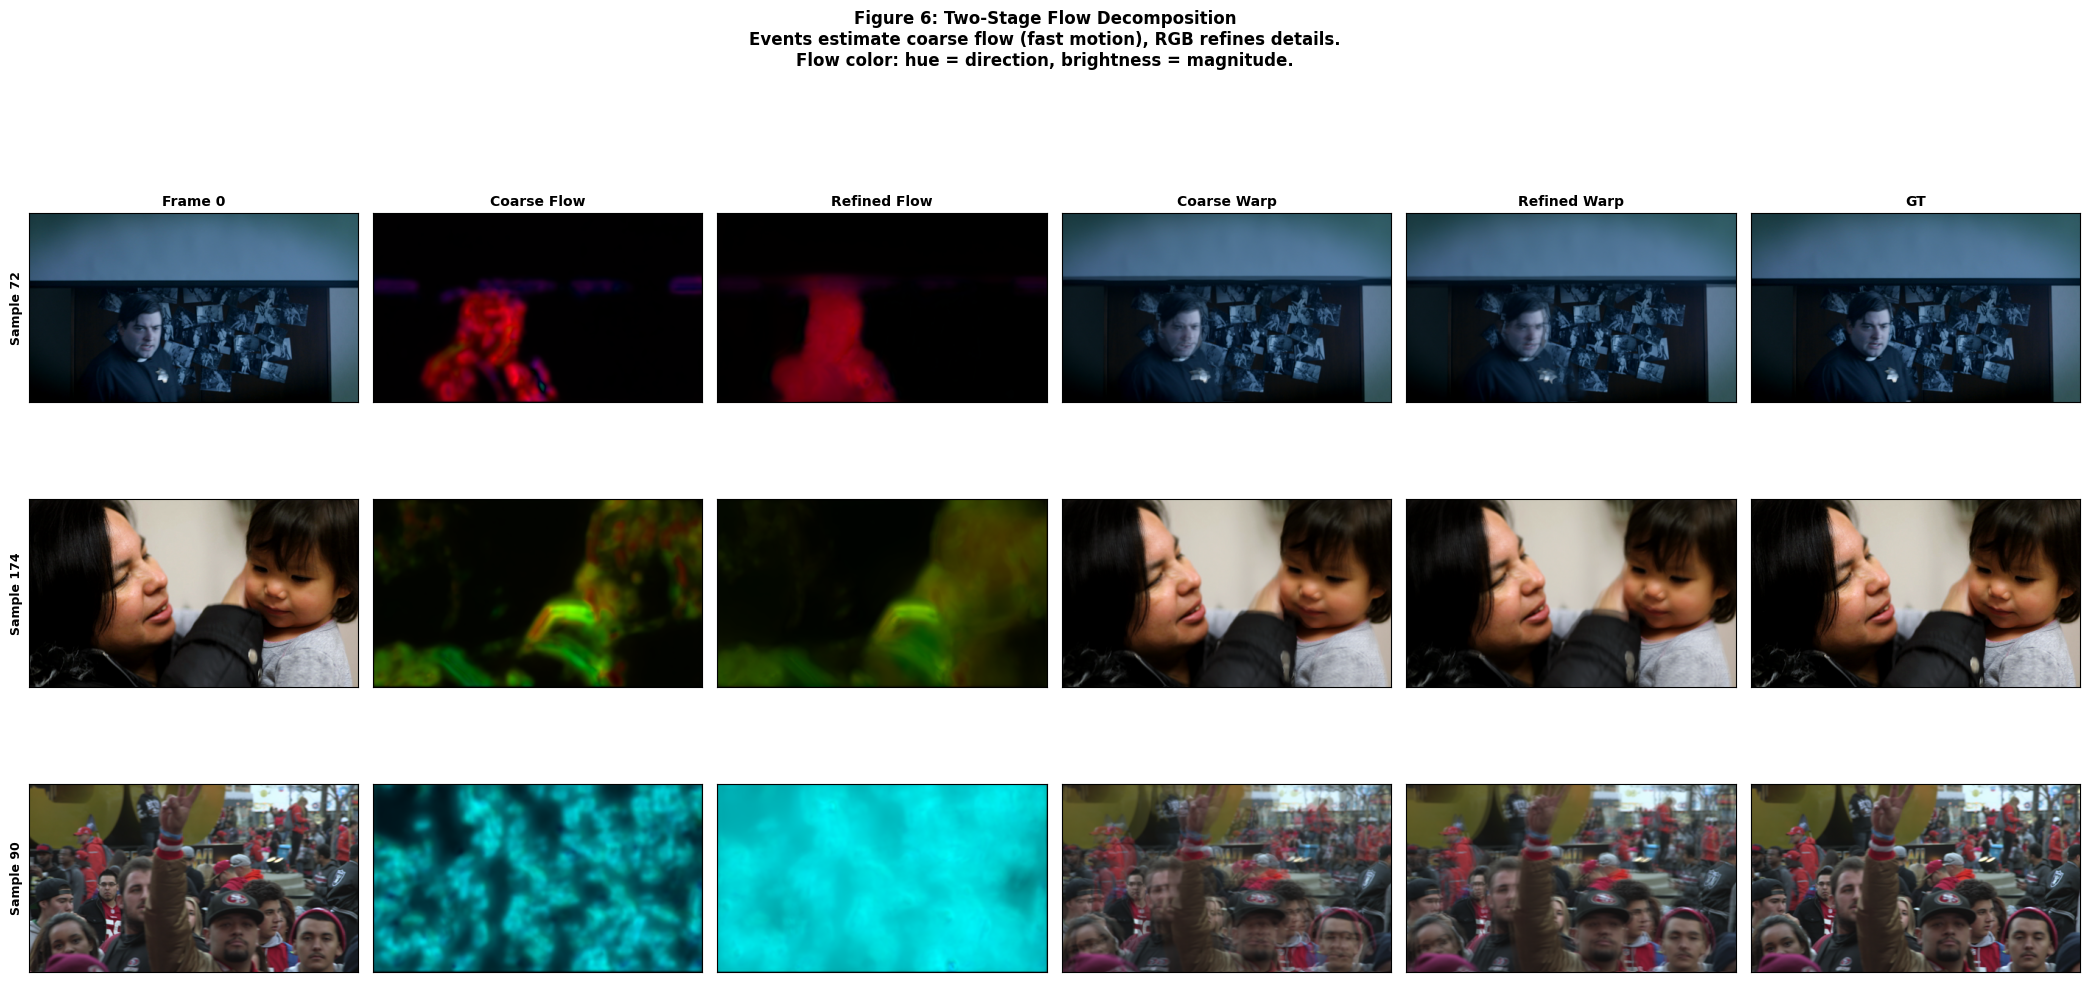

In [12]:
# Cell 8: Figure 6 — Flow Visualization (EventWarpNetV2)
# ============================================================================
# Show coarse flow (events-only) vs refined flow, warped frames, and flow color coding

def flow_to_color(flow_np, max_flow=None):
    """Convert (2, H, W) flow to RGB color image using HSV wheel encoding."""
    u, v = flow_np[0], flow_np[1]
    mag = np.sqrt(u**2 + v**2)
    ang = np.arctan2(v, u)
    if max_flow is None:
        max_flow = mag.max() + 1e-8
    hsv = np.zeros((*u.shape, 3), dtype=np.float32)
    hsv[..., 0] = (ang + np.pi) / (2 * np.pi)  # hue: direction
    hsv[..., 1] = 1.0                            # saturation
    hsv[..., 2] = np.clip(mag / max_flow, 0, 1)  # value: magnitude
    # HSV → RGB
    from matplotlib.colors import hsv_to_rgb
    return hsv_to_rgb(hsv)

if warpv2_model is None:
    print('No EventWarpNetV2 model loaded — skipping flow visualization.')
else:
    # Pick 3 samples
    flow_indices = [sample_indices[1], sample_indices[2], sample_indices[3]]

    fig, axes = plt.subplots(len(flow_indices), 6, figsize=(21, 3.5 * len(flow_indices)))
    col_titles = ['Frame 0', 'Coarse Flow', 'Refined Flow', 'Coarse Warp', 'Refined Warp', 'GT']

    for row, si in enumerate(flow_indices):
        f0, f1, voxel, gt = load_sample(si)

        # Get full outputs including flows
        f0p, pad_hw = pad_to_multiple(f0)
        f1p, _ = pad_to_multiple(f1)
        vp, _  = pad_to_multiple(voxel)
        with torch.no_grad():
            outputs = _forward(warpv2_model, f0p, f1p, vp)

        # EventWarpNetV2 returns (pred, flow_t0, flow_t1, flow_t0_c, flow_t1_c)
        pred = unpad(outputs[0].clamp(0, 1), pad_hw)
        flow_t0 = unpad(outputs[1], pad_hw)
        flow_t1 = unpad(outputs[2], pad_hw)
        flow_t0_c = unpad(outputs[3], pad_hw)
        flow_t1_c = unpad(outputs[4], pad_hw)

        # Coarse and refined warps
        coarse_warp = 0.5 * backwarp(f0, flow_t0_c) + 0.5 * backwarp(f1, flow_t1_c)
        refined_warp = 0.5 * backwarp(f0, flow_t0) + 0.5 * backwarp(f1, flow_t1)

        # Convert to numpy
        f0_np = to_numpy(f0)
        gt_np = to_numpy(gt)
        flow_c_np = flow_t0_c[0].cpu().numpy()
        flow_r_np = flow_t0[0].cpu().numpy()
        max_flow = max(np.abs(flow_c_np).max(), np.abs(flow_r_np).max())

        panels = [
            f0_np,
            flow_to_color(flow_c_np, max_flow),
            flow_to_color(flow_r_np, max_flow),
            to_numpy(coarse_warp.clamp(0, 1)),
            to_numpy(refined_warp.clamp(0, 1)),
            gt_np,
        ]

        for col, panel in enumerate(panels):
            axes[row, col].imshow(panel)
            if row == 0:
                axes[row, col].set_title(col_titles[col], fontsize=10, fontweight='bold')
            axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

        # Label rows
        axes[row, 0].set_ylabel(f'Sample {si}', fontsize=9, fontweight='bold')

    fig.suptitle('Figure 6: Two-Stage Flow Decomposition\n'
                 'Events estimate coarse flow (fast motion), RGB refines details.\n'
                 'Flow color: hue = direction, brightness = magnitude.',
                 fontsize=12, fontweight='bold', y=1.02)
    fig.tight_layout()
    save_fig(fig, 'fig6_flow_visualization')

Saved: /content/drive/MyDrive/493Project/figures/fig7_motion_stratified.png


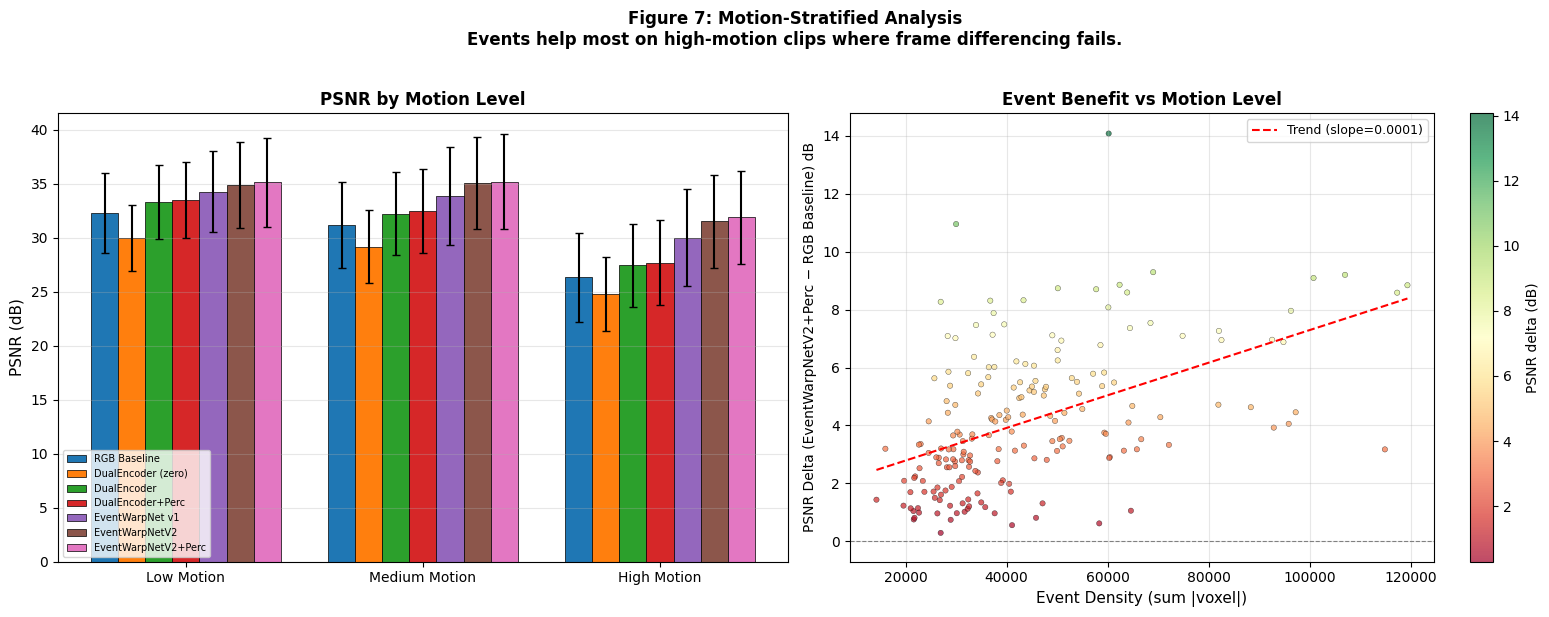

In [13]:
# Cell 9: Figure 7 — Motion-Stratified Analysis
# ============================================================================
# Split val set by event density into low/medium/high motion
# Bar chart: PSNR by motion level for each model
# Scatter: PSNR delta (best event model vs baseline) vs event density

if len(results) < 2:
    print('Need at least 2 models for motion-stratified analysis — skipping.')
else:
    # Stratify by event density terciles
    density_terciles = np.percentile(densities, [33, 67])
    motion_bins = np.digitize(densities, density_terciles)  # 0=low, 1=med, 2=high
    bin_labels = ['Low Motion', 'Medium Motion', 'High Motion']

    # Compute per-bin PSNR for each model
    stratified = {name: {b: [] for b in range(3)} for name in results}
    for name in results:
        psnr_all = results[name]['psnr_all']
        for i, psnr_val in enumerate(psnr_all):
            b = motion_bins[i] if i < len(motion_bins) else 1
            stratified[name][b].append(psnr_val)

    # --- Bar chart ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    model_names_strat = list(results.keys())
    n_bins = 3
    x = np.arange(n_bins)
    width = 0.8 / len(model_names_strat)

    for mi, mname in enumerate(model_names_strat):
        means = [np.mean(stratified[mname][b]) if stratified[mname][b] else 0 for b in range(3)]
        stds  = [np.std(stratified[mname][b])  if stratified[mname][b] else 0 for b in range(3)]
        offset = (mi - len(model_names_strat)/2 + 0.5) * width
        bars = ax1.bar(x + offset, means, width, yerr=stds, capsize=3, label=mname,
                       edgecolor='black', linewidth=0.5)

    ax1.set_xticks(x)
    ax1.set_xticklabels(bin_labels, fontsize=10)
    ax1.set_ylabel('PSNR (dB)', fontsize=11)
    ax1.set_title('PSNR by Motion Level', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=7, loc='lower left')
    ax1.grid(axis='y', alpha=0.3)

    # --- Scatter: PSNR delta vs event density ---
    # Find baseline and best event model
    baseline_name = None
    for n in results:
        if 'Baseline' in n:
            baseline_name = n
            break

    best_event_name = None
    best_psnr = 0
    for n in results:
        if 'Baseline' not in n and 'zero' not in n:
            if results[n]['psnr_mean'] > best_psnr:
                best_psnr = results[n]['psnr_mean']
                best_event_name = n

    if baseline_name and best_event_name:
        psnr_base = np.array(results[baseline_name]['psnr_all'])
        psnr_best = np.array(results[best_event_name]['psnr_all'])
        n_common = min(len(psnr_base), len(psnr_best), len(densities))
        delta = psnr_best[:n_common] - psnr_base[:n_common]
        dens_common = densities[:n_common]

        sc = ax2.scatter(dens_common, delta, c=delta, cmap='RdYlGn', s=15, alpha=0.7,
                         edgecolors='black', linewidth=0.3)
        ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax2.set_xlabel('Event Density (sum |voxel|)', fontsize=11)
        ax2.set_ylabel(f'PSNR Delta ({best_event_name} − {baseline_name}) dB', fontsize=10)
        ax2.set_title('Event Benefit vs Motion Level', fontsize=12, fontweight='bold')
        plt.colorbar(sc, ax=ax2, label='PSNR delta (dB)')
        ax2.grid(alpha=0.3)

        # Add trend line
        z = np.polyfit(dens_common, delta, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(dens_common.min(), dens_common.max(), 100)
        ax2.plot(x_trend, p(x_trend), 'r--', linewidth=1.5, label=f'Trend (slope={z[0]:.4f})')
        ax2.legend(fontsize=9)
    else:
        ax2.text(0.5, 0.5, 'Need baseline + event model\nfor delta analysis',
                 ha='center', va='center', transform=ax2.transAxes, fontsize=12)

    fig.suptitle('Figure 7: Motion-Stratified Analysis\n'
                 'Events help most on high-motion clips where frame differencing fails.',
                 fontsize=12, fontweight='bold', y=1.02)
    fig.tight_layout()
    save_fig(fig, 'fig7_motion_stratified')

In [14]:
# Cell 10: Figure 8 — GIF Comparisons (for digital poster / supplementary)
# ============================================================================
# 3-way side-by-side GIFs: GT | Best direct synthesis | Best flow-based

GIF_DIR = FIG_DIR / 'gifs'
GIF_DIR.mkdir(parents=True, exist_ok=True)

# Identify best direct synthesis and best flow-based models
best_direct = None
best_flow = None
for name in models_dict:
    if name in results:
        if 'Warp' in name or 'warp' in name:
            if best_flow is None or results[name]['psnr_mean'] > results[best_flow]['psnr_mean']:
                best_flow = name
        elif 'Baseline' not in name and 'zero' not in name:
            if best_direct is None or results[name]['psnr_mean'] > results[best_direct]['psnr_mean']:
                best_direct = name

gif_models = OrderedDict()
if best_direct:
    gif_models[best_direct] = models_dict[best_direct]
if best_flow:
    gif_models[best_flow] = models_dict[best_flow]

if not gif_models:
    print('Not enough models loaded for GIF comparison — skipping.')
else:
    print(f'GIF comparison: GT vs {" vs ".join(gif_models.keys())}')

    # Pick 8 random val samples
    rng_gif = np.random.RandomState(123)
    gif_indices = rng_gif.choice(len(val_ds), size=min(8, len(val_ds)), replace=False)

    for gi, si in enumerate(gif_indices):
        f0, f1, voxel, gt = load_sample(si)
        gt_np = to_numpy(gt)

        panels = [gt_np]
        labels = ['GT']
        for mname, model in gif_models.items():
            pred, _ = run_inference(model, f0, f1, voxel)
            panels.append(to_numpy(pred))
            labels.append(mname)

        # Build side-by-side frame
        h, w = panels[0].shape[:2]
        gap = 4
        canvas_w = w * len(panels) + gap * (len(panels) - 1)
        canvas = np.ones((h + 25, canvas_w, 3), dtype=np.float32)  # extra height for labels

        for pi, (panel, label) in enumerate(zip(panels, labels)):
            x_off = pi * (w + gap)
            canvas[25:25+h, x_off:x_off+w] = panel

        # Convert to uint8 PIL
        canvas_uint8 = (canvas * 255).clip(0, 255).astype(np.uint8)
        img = Image.fromarray(canvas_uint8)

        # Add text labels using matplotlib (save as individual frames)
        fig_gif, ax_gif = plt.subplots(1, 1, figsize=(canvas_w/100, (h+25)/100), dpi=100)
        ax_gif.imshow(canvas)
        for pi, label in enumerate(labels):
            x_center = pi * (w + gap) + w / 2
            ax_gif.text(x_center, 12, label, ha='center', va='center', fontsize=6,
                       fontweight='bold', color='black')
        ax_gif.axis('off')

        gif_path = GIF_DIR / f'comparison_{gi:02d}.png'
        fig_gif.savefig(str(gif_path), dpi=150, bbox_inches='tight', pad_inches=0.02)
        plt.close(fig_gif)

    # Create animated GIF from all comparison frames
    try:
        frames = []
        for gi in range(len(gif_indices)):
            frame_path = GIF_DIR / f'comparison_{gi:02d}.png'
            if frame_path.exists():
                frames.append(Image.open(str(frame_path)))

        if frames:
            gif_path = GIF_DIR / 'all_comparisons.gif'
            frames[0].save(
                str(gif_path), save_all=True, append_images=frames[1:],
                duration=1500, loop=0,
            )
            print(f'Saved animated GIF: {gif_path}')
    except Exception as e:
        print(f'GIF creation failed (non-critical): {e}')

    print(f'Saved {len(gif_indices)} comparison frames to {GIF_DIR}')

GIF comparison: GT vs DualEncoder+Perc vs EventWarpNetV2+Perc
Saved animated GIF: /content/drive/MyDrive/493Project/figures/gifs/all_comparisons.gif
Saved 8 comparison frames to /content/drive/MyDrive/493Project/figures/gifs


Saved: /content/drive/MyDrive/493Project/figures/fig9_training_curves.png


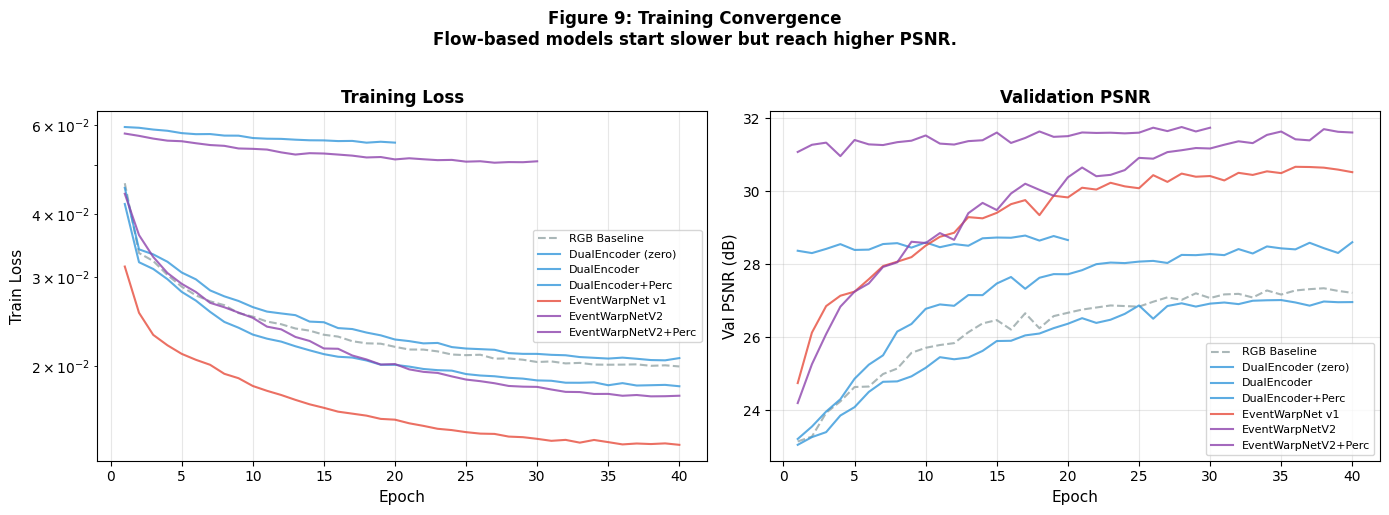

In [15]:
# Cell 11: Figure 9 — Training Curves
# ============================================================================
# Plot train loss and val PSNR over epochs for all models with training logs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Define line styles per model family
style_map = {
    'baseline': ('--', '#95a5a6'),
    'dual':     ('-',  '#3498db'),
    'warp':     ('-',  '#e74c3c'),
    'warp_v2':  ('-',  '#8e44ad'),
}

logs_found = 0
for name, info in CHECKPOINTS.items():
    log_path = CKPT_DIR / info['dir'] / 'training_log.json'
    if not log_path.exists():
        continue

    with open(str(log_path)) as f:
        log = json.load(f)

    if not log:
        continue

    logs_found += 1
    epochs     = [e['epoch'] for e in log]
    train_loss = [e['train_loss'] for e in log]
    val_psnr   = [e['val_psnr'] for e in log]

    ls, color = style_map.get(info['model_type'], ('-', 'gray'))

    ax1.plot(epochs, train_loss, ls, color=color, label=name, linewidth=1.5, alpha=0.8)
    ax2.plot(epochs, val_psnr,   ls, color=color, label=name, linewidth=1.5, alpha=0.8)

if logs_found == 0:
    print('No training logs found — skipping training curves figure.')
else:
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Train Loss', fontsize=11)
    ax1.set_title('Training Loss', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)
    ax1.set_yscale('log')

    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Val PSNR (dB)', fontsize=11)
    ax2.set_title('Validation PSNR', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

    fig.suptitle('Figure 9: Training Convergence\n'
                 'Flow-based models start slower but reach higher PSNR.',
                 fontsize=12, fontweight='bold', y=1.02)
    fig.tight_layout()
    save_fig(fig, 'fig9_training_curves')

In [16]:
# Cell 12: Summary Statistics — Print + Save CSV
# ============================================================================
import csv

print('\n' + '='*80)
print('FINAL RESULTS SUMMARY')
print('='*80)

# Build summary rows
rows = []
for name, r in results.items():
    info = CHECKPOINTS.get(name, {})
    model_type = info.get('model_type', '?')
    n_params = sum(p.numel() for p in models_dict[name].parameters()) / 1e6 if name in models_dict else 0
    rows.append({
        'Model': name,
        'Type': model_type,
        'Params (M)': f'{n_params:.1f}',
        'PSNR (dB)': f'{r["psnr_mean"]:.2f}',
        'PSNR std': f'{r["psnr_std"]:.2f}',
        'SSIM': f'{r["ssim_mean"]:.4f}',
        'SSIM std': f'{r["ssim_std"]:.4f}',
    })

# Print table
header = f'{"Model":<25} {"Type":<10} {"Params":<8} {"PSNR (dB)":<12} {"SSIM":<12}'
print(header)
print('-' * len(header))
for row in rows:
    print(f'{row["Model"]:<25} {row["Type"]:<10} {row["Params (M)"]:<8} '
          f'{row["PSNR (dB)"]:>5} ± {row["PSNR std"]:<5}  '
          f'{row["SSIM"]:>6} ± {row["SSIM std"]:<6}')

# Save CSV
csv_path = FIG_DIR / 'results_summary.csv'
with open(str(csv_path), 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print(f'\nCSV saved: {csv_path}')

# Also save per-sample PSNR for each model (useful for statistical tests)
per_sample_path = FIG_DIR / 'per_sample_psnr.csv'
with open(str(per_sample_path), 'w', newline='') as f:
    writer = csv.writer(f)
    header_row = ['sample_idx'] + list(results.keys())
    writer.writerow(header_row)
    n_samples_csv = min(len(r['psnr_all']) for r in results.values()) if results else 0
    for i in range(n_samples_csv):
        row_data = [i] + [results[n]['psnr_all'][i] for n in results]
        writer.writerow(row_data)
print(f'Per-sample PSNR saved: {per_sample_path}')

print('\n' + '='*80)
print(f'All figures saved to: {FIG_DIR}')
print('Figures generated:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}')
print('='*80)


FINAL RESULTS SUMMARY
Model                     Type       Params   PSNR (dB)    SSIM        
-----------------------------------------------------------------------
RGB Baseline              baseline   17.3     29.95 ± 4.71   0.8708 ± 0.1114
DualEncoder (zero)        dual       27.9     28.00 ± 3.99   0.8296 ± 0.1153
DualEncoder               dual       27.9     31.00 ± 4.51   0.8860 ± 0.0978
DualEncoder+Perc          dual       27.9     31.24 ± 4.55   0.8910 ± 0.0957
EventWarpNet v1           warp       13.4     32.73 ± 4.69   0.9219 ± 0.0795
EventWarpNetV2            warp_v2    15.1     33.83 ± 4.49   0.9408 ± 0.0651
EventWarpNetV2+Perc       warp_v2    15.1     34.09 ± 4.55   0.9450 ± 0.0627

CSV saved: /content/drive/MyDrive/493Project/figures/results_summary.csv
Per-sample PSNR saved: /content/drive/MyDrive/493Project/figures/per_sample_psnr.csv

All figures saved to: /content/drive/MyDrive/493Project/figures
Figures generated:
  fig1_what_events_encode.png
  fig2_architecture_c

---

# Poster Figures (Final)

**Layout: 3-column poster.** All figures use a shared **anchor sample** (medium-high motion)
for narrative coherence. See `POSTER_GUIDE.md` for full layout instructions.

Figures generated:
1. **Architecture** — EventWarpNetV2 pipeline only (compact), with real images
2. **Results table** — all models, PSNR/SSIM/Params (no bar chart)
3. **Qualitative grid** — hero figure, 3 samples × 4 models + error maps
4. **Attention gates** — single row: events → attention → overlay
5. **Flow decomposition** — single row: f0 → coarse → refined → pred → GT
6. **Motion scatter** — PSNR delta vs event density (the climax)

In [17]:
# Poster: Browse anchor candidates — pick the best one visually
# ============================================================================
# Shows the 40 samples closest to the 75th percentile event density.
# Each candidate displays as a GIF: f0 → GT → f1 so you can see the motion.
# Set ANCHOR_IDX in the next cell.

from IPython.display import display, HTML
import base64, io

target = np.percentile(densities, 75)
dists = np.abs(densities - target)
candidates = np.argsort(dists)[:100]

def tensor_to_pil(t):
    """(C,H,W) tensor [0,1] → PIL Image, resized for display."""
    img = Image.fromarray((t.permute(1,2,0).numpy().clip(0,1) * 255).astype(np.uint8))
    return img.resize((img.width // 2, img.height // 2), Image.BILINEAR)

html_parts = ['<div style="display:flex;flex-wrap:wrap;gap:8px;">']

for idx in candidates:
    f0, f1, voxel, gt = val_ds[idx]
    frames = [tensor_to_pil(f0), tensor_to_pil(gt), tensor_to_pil(f1)]

    # Build GIF in memory
    buf = io.BytesIO()
    frames[0].save(buf, format='GIF', save_all=True, append_images=frames[1:],
                   duration=400, loop=0)
    b64 = base64.b64encode(buf.getvalue()).decode()

    html_parts.append(
        f'<div style="text-align:center;">'
        f'<img src="data:image/gif;base64,{b64}" style="border:1px solid #ccc;"/>'
        f'<div style="font-size:11px;"><b>idx={idx}</b><br>density={densities[idx]:.0f}</div>'
        f'</div>'
    )

html_parts.append('</div>')
html_parts.append(f'<p style="margin-top:10px;font-size:13px;">'
                  f'<b>Target density: {target:.0f} (75th percentile)</b> — '
                  f'Pick an idx with clear motion and set ANCHOR_IDX in the next cell.</p>')

display(HTML(''.join(html_parts)))

Output hidden; open in https://colab.research.google.com to view.

In [18]:
# Poster: Set anchor sample + precompute intermediates
# ============================================================================
# >>> CHANGE THIS to the idx you picked from the grid above <<<
ANCHOR_IDX = 98  # e.g. ANCHOR_IDX = 142
# ============================================================================

if ANCHOR_IDX is None:
    # Default fallback: closest to 75th percentile
    ANCHOR_IDX = int(np.argmin(np.abs(densities - np.percentile(densities, 75))))
    print(f'No anchor set — using default idx={ANCHOR_IDX}')

print(f'Anchor sample: idx={ANCHOR_IDX}, event density={densities[ANCHOR_IDX]:.0f}')

f0_a, f1_a, voxel_a, gt_a = load_sample(ANCHOR_IDX)

# Precompute all intermediates for the anchor
anchor = {'f0': to_numpy(f0_a), 'f1': to_numpy(f1_a), 'gt': to_numpy(gt_a)}
anchor['events'] = voxel_a[0].cpu().numpy().sum(axis=0)
anchor['mean_frame'] = (anchor['f0'] + anchor['f1']) / 2

# Predictions from key models
for mname in ['RGB Baseline', 'DualEncoder', 'EventWarpNetV2+Perc']:
    if mname in models_dict:
        pred, _ = run_inference(models_dict[mname], f0_a, f1_a, voxel_a)
        anchor[f'pred_{mname}'] = to_numpy(pred)
        anchor[f'psnr_{mname}'] = calculate_psnr(pred, gt_a).item()

# EventWarpNetV2 intermediates (flows, warps, attention)
warpv2 = next((m for n, m in models_dict.items() if isinstance(m, EventWarpNetV2)), None)
if warpv2:
    f0p, pad_hw = pad_to_multiple(f0_a)
    f1p, _ = pad_to_multiple(f1_a)
    vp, _ = pad_to_multiple(voxel_a)
    with torch.no_grad():
        outs = _forward(warpv2, f0p, f1p, vp)
    anchor['warp_pred'] = to_numpy(unpad(outs[0].clamp(0,1), pad_hw))
    anchor['flow_t0'] = unpad(outs[1], pad_hw)
    anchor['flow_t0_c'] = unpad(outs[3], pad_hw)
    anchor['flow_t1_c'] = unpad(outs[4], pad_hw)
    coarse_w = (0.5*backwarp(f0_a, anchor['flow_t0_c']) + 0.5*backwarp(f1_a, anchor['flow_t1_c'])).clamp(0,1)
    anchor['coarse_warp'] = to_numpy(coarse_w)
    anchor['coarse_psnr'] = calculate_psnr(coarse_w, gt_a).item()
    anchor['warp_psnr'] = calculate_psnr(unpad(outs[0].clamp(0,1), pad_hw), gt_a).item()

    flow_c = anchor['flow_t0_c'][0].cpu().numpy()
    flow_r = anchor['flow_t0'][0].cpu().numpy()
    mf = max(np.abs(flow_c).max(), np.abs(flow_r).max()) + 1e-8
    anchor['coarse_flow_rgb'] = flow_to_color(flow_c, mf)
    anchor['refined_flow_rgb'] = flow_to_color(flow_r, mf)

print('Anchor precomputed.')

Anchor sample: idx=98, event density=38158
Anchor precomputed.


Saved: /content/drive/MyDrive/493Project/figures/poster_1_architecture.png


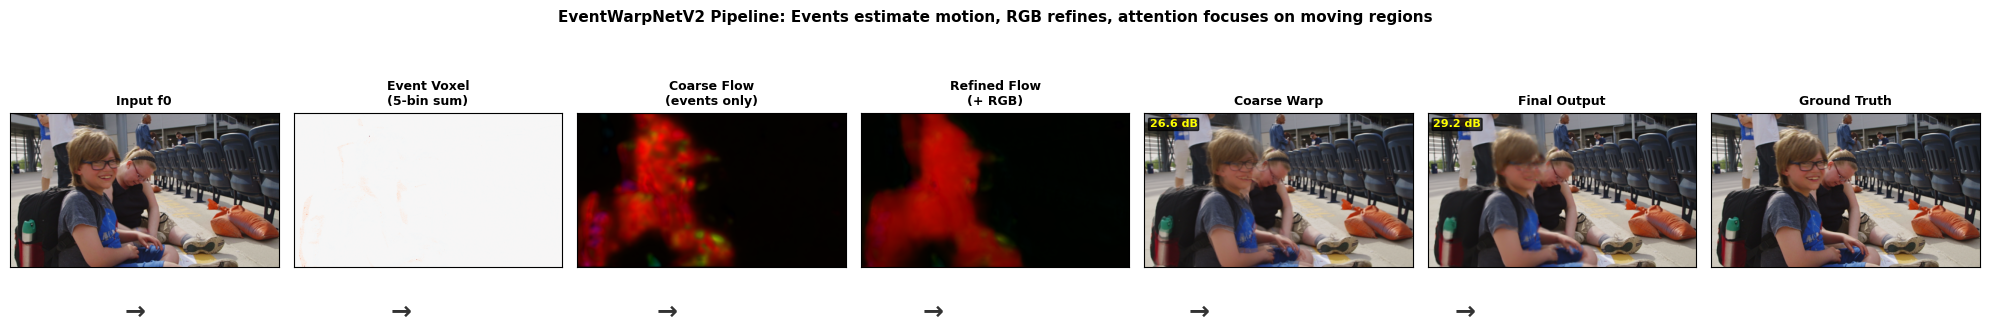

In [19]:
# Poster Fig 1: EventWarpNetV2 Architecture Pipeline (compact, real images)
# ============================================================================
# Single-row pipeline: f0 → Events → Coarse Flow → Refined Flow → Attentive Refine → Prediction
# Only V2 shown — other architectures described in results table.

if warpv2 is None:
    print('No EventWarpNetV2 loaded — skipping architecture figure.')
else:
    fig, axes = plt.subplots(1, 7, figsize=(20, 3))
    panels = [
        (anchor['f0'], 'Input f0'),
        (anchor['events'], 'Event Voxel\n(5-bin sum)'),
        (anchor['coarse_flow_rgb'], 'Coarse Flow\n(events only)'),
        (anchor['refined_flow_rgb'], 'Refined Flow\n(+ RGB)'),
        (anchor['coarse_warp'], 'Coarse Warp'),
        (anchor['warp_pred'], 'Final Output'),
        (anchor['gt'], 'Ground Truth'),
    ]

    for ax, (img, title) in zip(axes, panels):
        if img.ndim == 2:  # event voxel (single channel)
            vmax = max(abs(img.min()), abs(img.max())) + 1e-8
            ax.imshow(img, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        else:
            ax.imshow(img)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

    # PSNR labels on coarse warp and final
    axes[4].text(0.02, 0.96, f'{anchor["coarse_psnr"]:.1f} dB', transform=axes[4].transAxes,
                 fontsize=8, color='yellow', fontweight='bold', va='top',
                 bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.7))
    axes[5].text(0.02, 0.96, f'{anchor["warp_psnr"]:.1f} dB', transform=axes[5].transAxes,
                 fontsize=8, color='yellow', fontweight='bold', va='top',
                 bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.7))

    # Arrows between panels
    for i in range(6):
        fig.text(0.07 + i * 0.133, 0.02, '\u2192', fontsize=18, ha='center',
                 fontweight='bold', color='#333')

    fig.suptitle('EventWarpNetV2 Pipeline: Events estimate motion, RGB refines, attention focuses on moving regions',
                 fontsize=11, fontweight='bold', y=1.05)
    fig.tight_layout()
    save_fig(fig, 'poster_1_architecture')

Saved: /content/drive/MyDrive/493Project/figures/poster_2_results_table.png


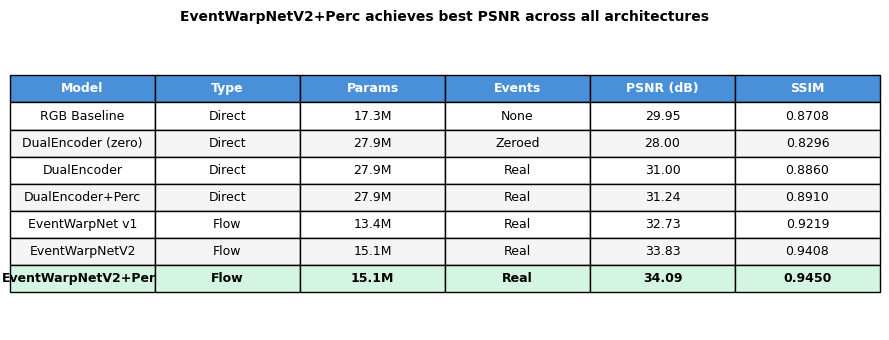

In [20]:
# Poster Fig 2: Results Table (compact, no bar chart)
# ============================================================================
# All models, PSNR/SSIM/Params. Best row highlighted. Table-only = more space-efficient.

poster_model_order = [
    'RGB Baseline', 'DualEncoder (zero)', 'DualEncoder', 'DualEncoder+Perc',
    'EventWarpNet v1', 'EventWarpNetV2', 'EventWarpNetV2+Perc',
]
avail = [(n, results[n]) for n in poster_model_order if n in results]

if not avail:
    print('No results — run Section 1 Cell 5 first.')
else:
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.axis('off')

    col_labels = ['Model', 'Type', 'Params', 'Events', 'PSNR (dB)', 'SSIM']
    row_data = []
    for name, r in avail:
        mtype = 'Direct' if 'Baseline' in name or 'Dual' in name else 'Flow'
        params = f'{sum(p.numel() for p in models_dict[name].parameters())/1e6:.1f}M' if name in models_dict else '—'
        if 'Baseline' in name: evt = 'None'
        elif 'zero' in name:   evt = 'Zeroed'
        else:                  evt = 'Real'
        row_data.append([name, mtype, params, evt,
                         f'{r["psnr_mean"]:.2f}', f'{r["ssim_mean"]:.4f}'])

    table = ax.table(cellText=row_data, colLabels=col_labels,
                     cellLoc='center', loc='center',
                     colColours=['#4A90D9']*len(col_labels))
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    # Header style
    for j in range(len(col_labels)):
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Highlight best row
    best_idx = max(range(len(avail)), key=lambda i: avail[i][1]['psnr_mean'])
    for j in range(len(col_labels)):
        table[best_idx + 1, j].set_facecolor('#d5f5e3')
        table[best_idx + 1, j].set_text_props(fontweight='bold')

    # Alternate shading
    for i in range(len(row_data)):
        if i != best_idx and i % 2 == 1:
            for j in range(len(col_labels)):
                table[i + 1, j].set_facecolor('#f5f5f5')

    ax.set_title('EventWarpNetV2+Perc achieves best PSNR across all architectures',
                  fontsize=10, fontweight='bold', pad=12)
    fig.tight_layout()
    save_fig(fig, 'poster_2_results_table')

Saved: /content/drive/MyDrive/493Project/figures/poster_3_qualitative.png


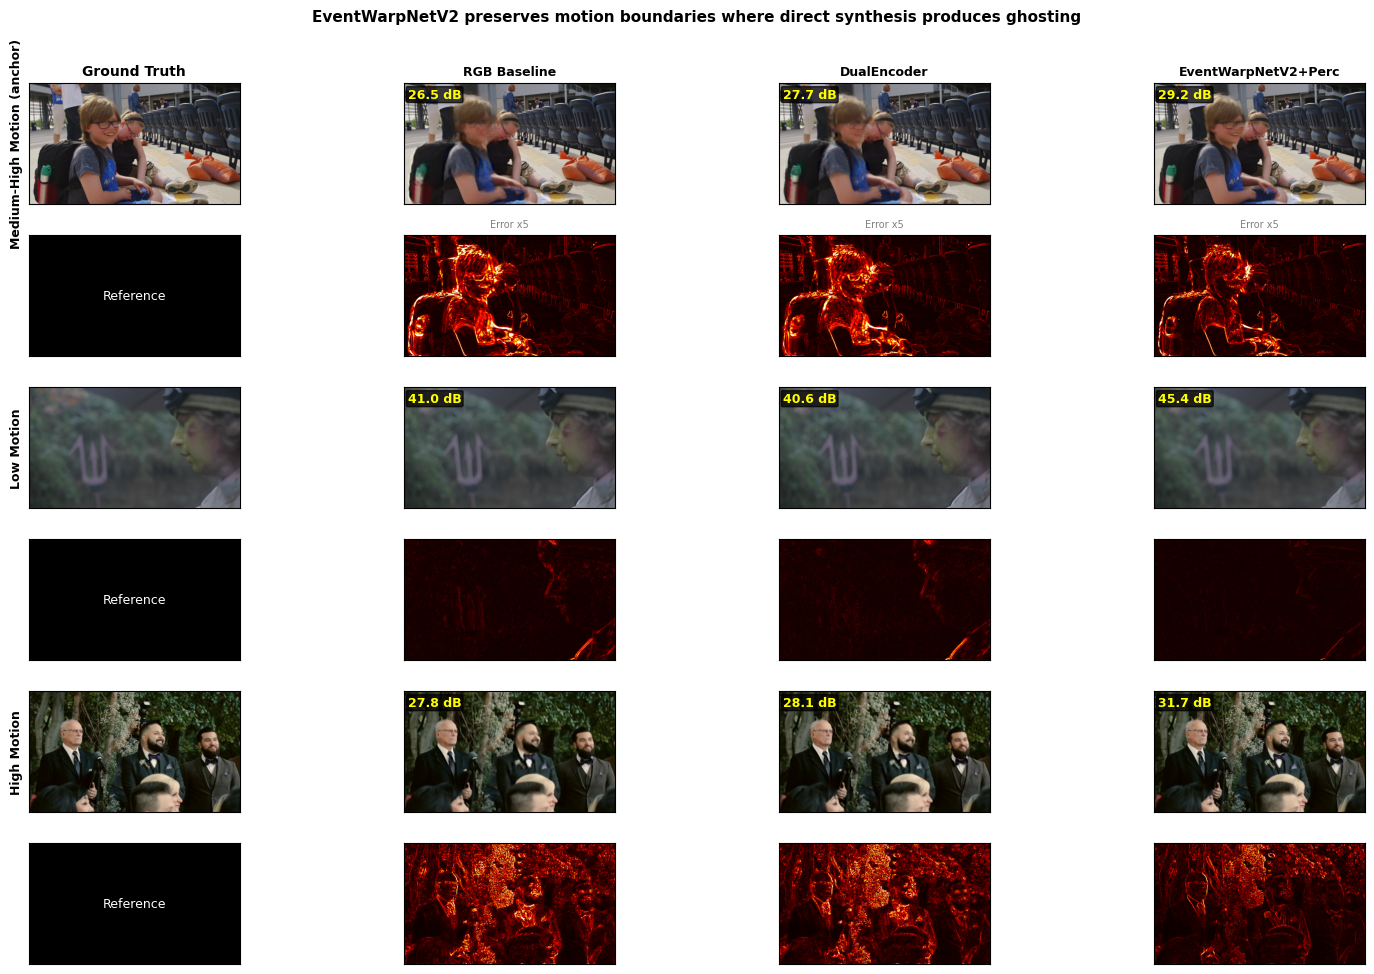

In [21]:
# Poster Fig 3: Qualitative Grid — HERO FIGURE
# ============================================================================
# 3 samples (anchor + low motion + high motion) × 4 models (GT, Baseline, DualEncoder, V2)
# Error maps same size as predictions. Anchor sample is row 1.

# Pick low and high motion samples (anchor is already medium-high)
low_target = np.percentile(densities, 20)
high_target = np.percentile(densities, 95)
low_idx = int(np.argmin(np.abs(densities - low_target)))
high_idx = int(np.argmin(np.abs(densities - high_target)))
if low_idx == ANCHOR_IDX: low_idx = (low_idx + 1) % len(densities)
if high_idx == ANCHOR_IDX: high_idx = (high_idx + 1) % len(densities)

qual_samples = [
    (ANCHOR_IDX, 'Medium-High Motion (anchor)'),
    (low_idx, 'Low Motion'),
    (high_idx, 'High Motion'),
]

qual_models = [n for n in ['RGB Baseline', 'DualEncoder', 'EventWarpNetV2+Perc'] if n in models_dict]

if not qual_models:
    print('Not enough models for qualitative grid.')
else:
    n_cols = 1 + len(qual_models)  # GT + models
    n_rows = len(qual_samples) * 2  # pred + error per sample

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * len(qual_samples)))

    for si_idx, (si, mtag) in enumerate(qual_samples):
        f0, f1, voxel, gt = load_sample(si)
        gt_np = to_numpy(gt)
        pr = si_idx * 2
        er = si_idx * 2 + 1

        # GT column
        axes[pr, 0].imshow(gt_np)
        axes[er, 0].imshow(np.zeros_like(gt_np))
        axes[er, 0].text(0.5, 0.5, 'Reference', ha='center', va='center',
                          transform=axes[er, 0].transAxes, fontsize=9, color='white')
        if si_idx == 0:
            axes[pr, 0].set_title('Ground Truth', fontsize=10, fontweight='bold')
        axes[pr, 0].set_ylabel(mtag, fontsize=9, fontweight='bold')

        for mi, mname in enumerate(qual_models):
            model = models_dict[mname]
            pred, _ = run_inference(model, f0, f1, voxel)
            pred_np = to_numpy(pred)
            psnr_val = calculate_psnr(pred, gt).item()

            axes[pr, mi+1].imshow(pred_np)
            axes[pr, mi+1].text(0.02, 0.96, f'{psnr_val:.1f} dB',
                                 transform=axes[pr, mi+1].transAxes,
                                 fontsize=9, color='yellow', fontweight='bold', va='top',
                                 bbox=dict(boxstyle='round,pad=0.12', facecolor='black', alpha=0.7))

            error = np.abs(pred_np - gt_np).mean(axis=-1) * 5.0
            axes[er, mi+1].imshow(error, cmap='hot', vmin=0, vmax=1)

            if si_idx == 0:
                axes[pr, mi+1].set_title(mname, fontsize=9, fontweight='bold')
                axes[er, mi+1].set_title('Error x5', fontsize=7, color='gray')

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle('EventWarpNetV2 preserves motion boundaries where direct synthesis produces ghosting',
                 fontsize=11, fontweight='bold', y=1.01)
    fig.tight_layout()
    save_fig(fig, 'poster_3_qualitative')

Saved: /content/drive/MyDrive/493Project/figures/poster_4_attention.png


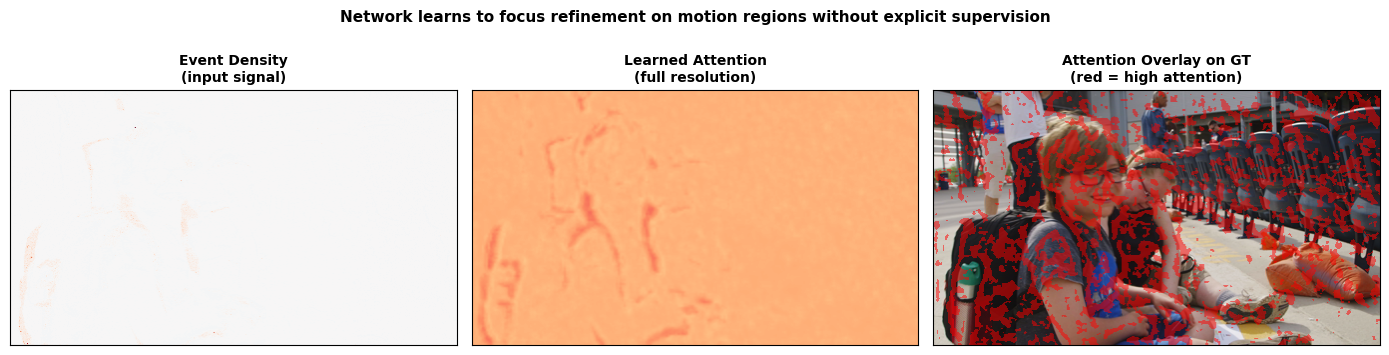

In [22]:
# Poster Fig 4: Attention Gates (single row, anchor sample)
# ============================================================================
# Events sum → Learned attention (full scale) → Overlay on GT
# Shows network learns to focus on motion without explicit supervision.

if warpv2 is None:
    print('No EventWarpNetV2 loaded — skipping attention figure.')
else:
    attention_maps_p = {}
    def make_hook_p(gate_name):
        def hook_fn(module, input, output):
            events = input[1]
            with torch.no_grad():
                attn = torch.sigmoid(module.conv2(F.relu(module.gn(module.conv1(events)))))
            attention_maps_p[gate_name] = attn.detach().cpu()
        return hook_fn

    hooks_p = []
    rn = warpv2.refinenet
    hooks_p.append(rn.attn1.register_forward_hook(make_hook_p('attn1')))

    # Run on anchor sample
    attention_maps_p.clear()
    _ = run_inference(warpv2, f0_a, f1_a, voxel_a)

    gt_np = anchor['gt']
    voxel_sum = anchor['events']

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

    # Events
    vmax = max(abs(voxel_sum.min()), abs(voxel_sum.max())) + 1e-8
    axes[0].imshow(voxel_sum, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[0].set_title('Event Density\n(input signal)', fontsize=10, fontweight='bold')

    # Attention
    if 'attn1' in attention_maps_p:
        attn = attention_maps_p['attn1'][0].mean(dim=0).numpy()
        attn_up = np.array(Image.fromarray(attn).resize(
            (gt_np.shape[1], gt_np.shape[0]), Image.BILINEAR))
        axes[1].imshow(attn_up, cmap='magma', vmin=0, vmax=1)
        axes[1].set_title('Learned Attention\n(full resolution)', fontsize=10, fontweight='bold')

        # Overlay
        overlay = gt_np.copy()
        mask = attn_up > np.percentile(attn_up, 70)
        overlay[mask, 0] = np.clip(overlay[mask, 0] * 0.5 + 0.5, 0, 1)
        overlay[mask, 1] *= 0.5
        overlay[mask, 2] *= 0.5
        axes[2].imshow(overlay)
        axes[2].set_title('Attention Overlay on GT\n(red = high attention)', fontsize=10, fontweight='bold')

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])

    for h in hooks_p:
        h.remove()

    fig.suptitle('Network learns to focus refinement on motion regions without explicit supervision',
                 fontsize=11, fontweight='bold', y=1.05)
    fig.tight_layout()
    save_fig(fig, 'poster_4_attention')

Saved: /content/drive/MyDrive/493Project/figures/poster_5_flow.png


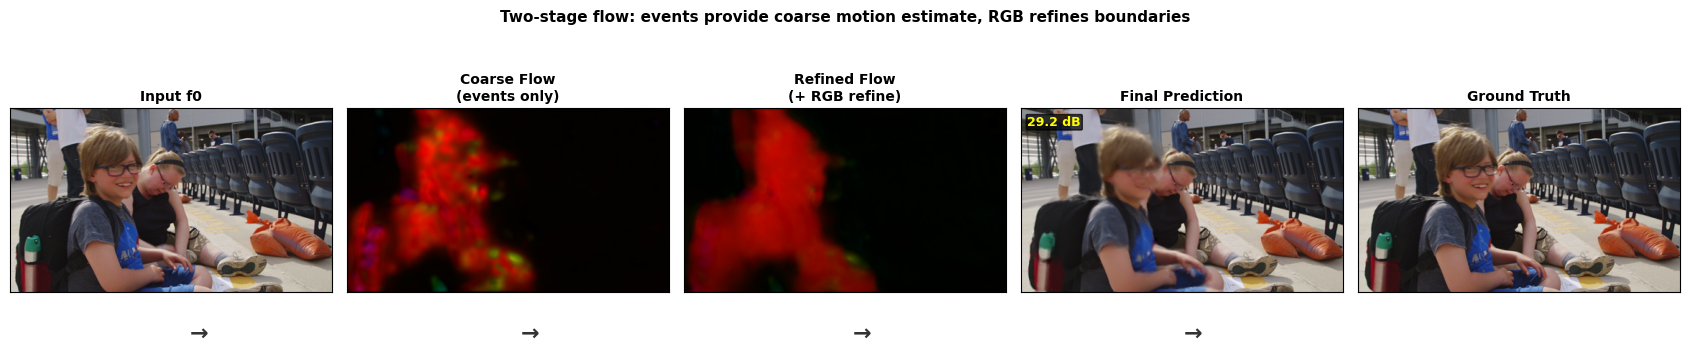

In [23]:
# Poster Fig 5: Flow Decomposition (single row, anchor sample)
# ============================================================================
# f0 → Coarse Flow → Refined Flow → Prediction → GT
# Shows two-stage decomposition: events handle fast motion, RGB refines.

if warpv2 is None:
    print('No EventWarpNetV2 loaded — skipping flow figure.')
else:
    fig, axes = plt.subplots(1, 5, figsize=(17, 3.2))
    panels = [
        (anchor['f0'], 'Input f0'),
        (anchor['coarse_flow_rgb'], 'Coarse Flow\n(events only)'),
        (anchor['refined_flow_rgb'], 'Refined Flow\n(+ RGB refine)'),
        (anchor['warp_pred'], 'Final Prediction'),
        (anchor['gt'], 'Ground Truth'),
    ]

    for ax, (img, title) in zip(axes, panels):
        ax.imshow(img)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

    # PSNR on prediction
    axes[3].text(0.02, 0.96, f'{anchor["warp_psnr"]:.1f} dB', transform=axes[3].transAxes,
                 fontsize=9, color='yellow', fontweight='bold', va='top',
                 bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.7))

    for i in range(4):
        fig.text(0.12 + i * 0.195, 0.02, '\u2192', fontsize=16, ha='center',
                 fontweight='bold', color='#333')

    fig.suptitle('Two-stage flow: events provide coarse motion estimate, RGB refines boundaries',
                 fontsize=11, fontweight='bold', y=1.05)
    fig.tight_layout()
    save_fig(fig, 'poster_5_flow')

Saved: /content/drive/MyDrive/493Project/figures/poster_6_motion_scatter.png


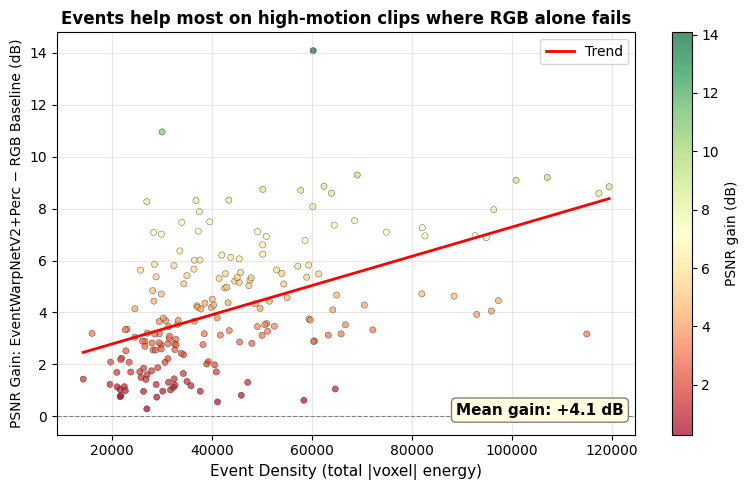

In [24]:
# Poster Fig 6: Motion-Stratified Scatter — THE CLIMAX
# ============================================================================
# PSNR delta (best event model - RGB baseline) vs event density
# Proves: events help most on high-motion clips where RGB alone fails.

baseline_name = next((n for n in results if 'Baseline' in n), None)
best_event_name = None
best_psnr_val = 0
for n in results:
    if 'Baseline' not in n and 'zero' not in n:
        if results[n]['psnr_mean'] > best_psnr_val:
            best_psnr_val = results[n]['psnr_mean']
            best_event_name = n

if not baseline_name or not best_event_name:
    print('Need baseline + event model for scatter.')
else:
    psnr_base = np.array(results[baseline_name]['psnr_all'])
    psnr_best = np.array(results[best_event_name]['psnr_all'])
    n_common = min(len(psnr_base), len(psnr_best), len(densities))
    delta = psnr_best[:n_common] - psnr_base[:n_common]
    dens = densities[:n_common]

    fig, ax = plt.subplots(figsize=(8, 5))
    sc = ax.scatter(dens, delta, c=delta, cmap='RdYlGn', s=20, alpha=0.7,
                    edgecolors='black', linewidth=0.3)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    # Trend line (no slope annotation — raw slope is misleading)
    z = np.polyfit(dens, delta, 1)
    p = np.poly1d(z)
    x_trend = np.linspace(dens.min(), dens.max(), 100)
    ax.plot(x_trend, p(x_trend), 'r-', linewidth=2, label='Trend')

    ax.set_xlabel('Event Density (total |voxel| energy)', fontsize=11)
    ax.set_ylabel(f'PSNR Gain: {best_event_name} \u2212 {baseline_name} (dB)', fontsize=10)
    ax.set_title('Events help most on high-motion clips where RGB alone fails',
                 fontsize=12, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='PSNR gain (dB)')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    # Annotate mean gain
    mean_gain = delta.mean()
    ax.text(0.98, 0.05, f'Mean gain: +{mean_gain:.1f} dB',
            transform=ax.transAxes, ha='right', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

    fig.tight_layout()
    save_fig(fig, 'poster_6_motion_scatter')

Saved: /content/drive/MyDrive/493Project/figures/poster_6b_motion_normalized.png


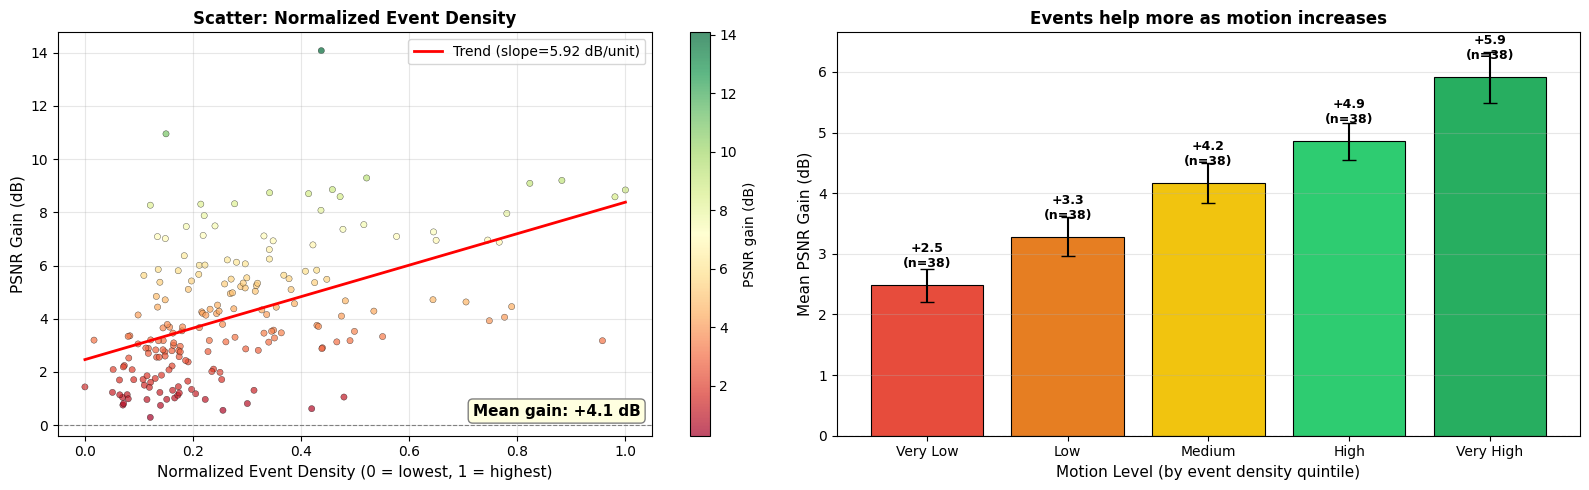

Normalized slope: 5.92 dB per unit normalized density


In [25]:
# Poster Fig 6b: Normalized Event Density + Binned Bar Chart
# ============================================================================
# Two alternative versions:
#   (a) Scatter with normalized event density (0-1 scale, log option)
#   (b) Binned bar chart — mean PSNR gain per motion quantile

if baseline_name and best_event_name:
    psnr_base = np.array(results[baseline_name]['psnr_all'])
    psnr_best = np.array(results[best_event_name]['psnr_all'])
    n_common = min(len(psnr_base), len(psnr_best), len(densities))
    delta = psnr_best[:n_common] - psnr_base[:n_common]
    dens = densities[:n_common]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # ---- (a) Normalized scatter with log x-axis ----
    dens_norm = (dens - dens.min()) / (dens.max() - dens.min() + 1e-8)
    sc = ax1.scatter(dens_norm, delta, c=delta, cmap='RdYlGn', s=20, alpha=0.7,
                     edgecolors='black', linewidth=0.3)

    # Trend line on normalized density
    z = np.polyfit(dens_norm, delta, 1)
    p = np.poly1d(z)
    x_trend = np.linspace(0, 1, 100)
    ax1.plot(x_trend, p(x_trend), 'r-', linewidth=2,
             label=f'Trend (slope={z[0]:.2f} dB/unit)')
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax1.set_xlabel('Normalized Event Density (0 = lowest, 1 = highest)', fontsize=11)
    ax1.set_ylabel(f'PSNR Gain (dB)', fontsize=11)
    ax1.set_title('Scatter: Normalized Event Density', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax1, label='PSNR gain (dB)')

    mean_gain = delta.mean()
    ax1.text(0.98, 0.05, f'Mean gain: +{mean_gain:.1f} dB',
             transform=ax1.transAxes, ha='right', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

    # ---- (b) Binned bar chart (quintiles) ----
    n_bins = 5
    bin_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    bin_edges = np.percentile(dens, np.linspace(0, 100, n_bins + 1))
    bin_idx = np.digitize(dens, bin_edges[1:-1])  # 0 to n_bins-1

    bin_means = []
    bin_stds = []
    bin_counts = []
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() > 0:
            bin_means.append(delta[mask].mean())
            bin_stds.append(delta[mask].std() / np.sqrt(mask.sum()))  # SEM
            bin_counts.append(mask.sum())
        else:
            bin_means.append(0)
            bin_stds.append(0)
            bin_counts.append(0)

    colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
    bars = ax2.bar(bin_labels, bin_means, yerr=bin_stds, capsize=5,
                   color=colors, edgecolor='black', linewidth=0.8)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax2.set_xlabel('Motion Level (by event density quintile)', fontsize=11)
    ax2.set_ylabel('Mean PSNR Gain (dB)', fontsize=11)
    ax2.set_title('Events help more as motion increases', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    # Annotate counts
    for bar, count, mean in zip(bars, bin_counts, bin_means):
        ax2.text(bar.get_x() + bar.get_width() / 2, mean + 0.3,
                 f'+{mean:.1f}\n(n={count})', ha='center', fontsize=9, fontweight='bold')

    fig.tight_layout()
    save_fig(fig, 'poster_6b_motion_normalized')
    print(f'Normalized slope: {z[0]:.2f} dB per unit normalized density')
else:
    print('Need baseline + event model — skipping.')